# Chartbook — every series, plotted

A companion to [`derivation.ipynb`](derivation.ipynb). That notebook explains
*how* each series was built; this one *shows* each one, so the construction can
be eyeballed rather than taken on trust.

One chart per series, organised **country → category → series**, then a
separate section reconciling our totals against the IMF WEO.

Everything is read from [`../deliverables/`](../deliverables) and nothing is
recomputed.

## How to read a chart

Each chart plots one series in **levels, millions of national currency**, with
the year on the x-axis.

| element | meaning |
|---|---|
| <span style="color:#2a78d6">**solid blue**</span> | the `strict` variant — official published sources only |
| <span style="color:#eb6834">**dashed orange**</span> | the `maximum_extension` variant — strict plus proxy, composite and partial-coverage legs. Drawn only where it goes further than strict; where you see one line, the two coincide exactly |
| grey shading | **projection territory** — every year after that series' last outturn, drawn on every chart whether or not the series reaches into it |
| `no projection published` | the series stops at the shading edge: nobody publishes a forecast of it that this project can use. The caption says which of the five reasons applies |
| dotted vertical rules | **seams** — a year where the source or the construction method changes. This is where to look for steps, kinks and level shifts |
| caption under the chart | the ordered recipe, then how far each variant projects and why it stops there |

Four things to keep in mind while scanning:

* **The x-axis is shared across every chart in a country** (sections 1–3), so
  charts can be laid beside each other and read against the same calendar:
  1965–2030 for the UK, 1965–2070 for France, 1991–2070 for Germany. The price
  is that most series occupy only part of the width — France's axis runs to
  2070 because four of its 24 series do. Two escape hatches, both in the setup
  cell: pass `xlim=(1990, 2030)` to any single chart to zoom in, or uncomment
  the two lines at the end of the `XLIM` block to put all three countries on
  one shared calendar. Sections 4 and 5 compare two lines *inside* one chart,
  so they keep their own spans; the note there says why.
* **The shading starts where the outturn ends, not where the chart ends.** A
  series with no forecast has its shading start at the same place as one with a
  long forecast — the difference is whether a line continues into it.
* **The y-axis is not zeroed.** These are levels over decades, autoscaled, so a
  wobble that looks dramatic may be a fraction of a percent. Read the axis.
* **A seam without a visible kink is the good case.** Every stitch is a growth
  rate chained onto an anchor, so a clean join should be invisible; a step at a
  dotted line is the thing worth asking about.

## Series that do not fit this schema

You asked to be told. Ten things sit awkwardly in a flat country → category →
series layout, and all ten are visible in the charts once you know to look:

1. **Every series is really two series.** `strict` and `maximum_extension` are
   separate constructions, so each chart carries up to two lines. They agree
   exactly wherever both exist — 2,724 year-values, zero disagreement — and the
   orange line appears only where the maximum variant reaches further. It
   reaches further at **both ends**: a longer forecast, and (for GBR R02,
   FRA R04/R06, DEU R04/R06) a longer *backward* leg where the backward source
   grades C.
2. **`GF01_X` is an identity, not a source.** It is `GF01 − GF01_7`, and by
   construction it is never forecast. Its chart always stops at the last
   outturn, and it is the only expenditure line that does.
3. **`TE` and `TR` are totals, not members of the 66 line series.** They live
   in the same files and are charted at the end of each category, but they are
   envelopes: they constrain the lines and carry no stitched forecast path of
   their own.
4. **The balance ledger is a different kind of object.** Its TR and TE are the
   *balance anchor's own published totals*, not sums of the lines charted above
   them; NLB, NI and PB are derived from those. It is **outturn-only** — there
   are no projection years at all — so those five charts stop earlier than the
   tree charts do. And the two variants are identical in the ledger, so every
   ledger chart is a single line.
5. **The UK therefore has two different TE numbers**, from two different ONS
   tables. That is expected, not a bug, and §5 charts the difference: under
   0.02% until 2023, 0.51% in 2024. France differs by at most 0.055%, Germany
   by nothing.
6. **The WEO level comparison only exists over the overlap years.** Our ledger
   has no forecast, so the "ours vs WEO" charts in §4 are history-only and stop
   at 2024/2025. There is no honest level chart of the forecast side.
7. **`weo_reconciliation.csv` is not a time series at all.** It holds
   contributions in percentage points of GDP, keyed by WEO vintage, base year
   and horizon. Only one of its components — `explained_share` — can be plotted
   against time, and §4.4 does that instead of a level comparison.
8. **Horizon asymmetry.** FRA and DEU `GF07`, `GF09` and `GF10` run to 2070 and
   `GF01_7` to 2036, against a history starting in 1991 or 1995. Those charts
   are mostly shaded. Read the unshaded part as data and the rest as somebody
   else's projection.
9. **Some series have interior gaps.** Net interest and the primary balance are
   blank in 16 ledger rows — the early UK years and 2025 everywhere — because
   one of the two interest legs does not reach. The line breaks rather than
   interpolating across the hole.
10. **`pct_gdp` does not span what levels span.** GDP is missing for 60 rows —
    France before 1975, where Eurostat's GDP series starts but the OECD tax
    series does not. This chartbook plots levels, so it is unaffected; a
    %-of-GDP chartbook would lose France's first decade.

In [1]:
from pathlib import Path
from textwrap import fill

import matplotlib.pyplot as plt
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "deliverables" / "series_catalogue.csv").exists())
DELIV = ROOT / "deliverables"
load = lambda n: pd.read_csv(DELIV / f"{n}.csv")

EXPENDITURE = load("expenditure_cofog")
REVENUE = load("revenue_esa")
TREE = pd.concat([EXPENDITURE, REVENUE], ignore_index=True)
LEDGER = load("balance_ledger")
LEVELS = load("weo_levels_bridge")
RECON = load("weo_reconciliation")
CATALOGUE = load("series_catalogue")

LATEST = sorted(LEVELS.weo_vintage.dropna().unique())[-1]
NAME = dict(zip(CATALOGUE.iso3, CATALOGUE.country))

# Categorical slots 1-3 of the validated palette, assigned by entity and never
# reused: blue is always our strict series, orange always the maximum
# extension, aqua always the IMF WEO. Line style repeats the distinction so
# identity never rests on colour alone.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED, AXIS = "#0b0b0b", "#898781", "#c3c2b7"
SURFACE, SHADE = "#fcfcfb", "#eceae4"

plt.rcParams.update({
    "figure.figsize": (7.2, 2.9), "figure.dpi": 90,
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK, "axes.titlecolor": INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelsize": 9, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "grid.color": AXIS, "grid.alpha": 0.45, "grid.linewidth": 0.6,
    "legend.frameon": False, "legend.fontsize": 8.5,
    "lines.linewidth": 2,
})


# One x-axis per country, spanning every year that country publishes on any
# series or in its ledger, so charts in sections 1-3 can be laid beside each
# other and read against the same calendar. Sections 4 and 5 are comparisons
# within a single chart and keep their own spans (see the notes below).
XLIM = {}
for _iso in TREE.iso3.unique():
    _years = pd.concat([TREE.query("iso3 == @_iso").year,
                        LEDGER.query("iso3 == @_iso").year])
    _lo, _hi = int(_years.min()), int(_years.max())
    XLIM[_iso] = (_lo - (_hi - _lo) * 0.02, _hi + (_hi - _lo) * 0.02)

# To read all three countries against one calendar instead of one each,
# uncomment these two lines and re-run from here:
# _ALL = (min(lo for lo, _ in XLIM.values()), max(hi for _, hi in XLIM.values()))
# XLIM = {iso: _ALL for iso in XLIM}


def thousands(ax):
    """Levels run to seven figures; unseparated tick labels are unreadable."""
    ax.yaxis.set_major_formatter(
        plt.matplotlib.ticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))


def _seams(g):
    """Years where the source or the construction method changes."""
    g = g.sort_values("year")
    key = list(zip(g.observation_type, g.source_id.fillna("")))
    return [int(y) for (a, b), y in zip(zip(key, key[1:]), g.year[1:]) if a != b]


# Why a series carries no projection. The pipeline records one of five
# statuses per undeclared line; these are the plain-language readings.
WHY_NO_FORECAST = {
    "no_official_forecast":
        "nobody publishes a forecast of this line on a compatible concept",
    "source_blocked":
        "a forecast exists but the publication cannot be ingested",
    "grade_below_strict":
        "the only candidate covers too little of the line to enter strict",
    "no_machine_readable_source":
        "the candidate source has no ESA-complete machine-readable series",
    "not_extended":
        "a total, deliberately not given a forecast path of its own",
}


def _forecast_lines(row):
    """State, in words, how far each variant projects and why it stops."""
    actual = int(row.final_actual_year)
    out = [f"outturn:  {int(row.first_year)}-{actual}"]
    reason = row.reason_series_ends if isinstance(row.reason_series_ends, str) else ""
    note = row.forecast_note if isinstance(row.forecast_note, str) else ""
    status = row.forecast_status if isinstance(row.forecast_status, str) else ""
    headline = WHY_NO_FORECAST.get(status, "")

    for variant, end in (("strict", int(row.final_strict_year)),
                         ("maximum", int(row.final_maximum_year))):
        label = f"{variant}:".ljust(9)
        if end > actual:
            why = reason or "source horizon"
            out.append(f"{label} projects to {end} — {why}")
        else:
            why = note or reason or "no forecast source identified"
            out.append(f"{label} NO PROJECTION — {headline or 'see note'}."
                       f" {why}")
    return out


def _caption(iso3, line_code):
    row = CATALOGUE.query("iso3 == @iso3 and line_code == @line_code").iloc[0]
    recipe = str(row.recipe_maximum_extension).replace(" | ", "  ·  ")
    parts = [fill(f"recipe:   {recipe}", 104, subsequent_indent=" " * 10)]
    parts += [fill(line, 104, subsequent_indent=" " * 10)
              for line in _forecast_lines(row)]
    return "\n".join(parts)


def chart(iso3, line_code, caption=True, xlim=None):
    """One series, both variants, with its seams and projection region.

    `xlim` overrides the shared country axis to zoom in on a stretch.
    """
    g = TREE.query("iso3 == @iso3 and line_code == @line_code")
    strict = g.query("variant == 'strict'").sort_values("year")
    mx = g.query("variant == 'maximum_extension'").sort_values("year")
    label = g.line_label.iloc[0]
    actual = g.query("basis == 'actual'").year.max()

    fig, ax = plt.subplots()
    # The projection region is shaded on every chart, whether or not the
    # series reaches into it: a line that stops at the shading edge is one
    # nobody publishes a forecast for, and that should look different from a
    # line that carries on.
    lo, hi = xlim or XLIM[iso3]
    ax.set_xlim(lo, hi)
    ax.axvspan(actual, hi, color=SHADE, zorder=0, lw=0)
    if len(mx) > len(strict):
        ax.plot(mx.year, mx.value_lcu_mn, color=ORANGE, ls="--",
                label="maximum_extension")
    ax.plot(strict.year, strict.value_lcu_mn, color=BLUE, label="strict")
    for year in _seams(mx):
        ax.axvline(year, color=MUTED, ls=":", lw=0.9, alpha=0.8, zorder=1)
    if mx.year.max() <= actual:
        ax.annotate("no projection published", (actual, 0.94),
                    xycoords=("data", "axes fraction"),
                    xytext=(4, 0), textcoords="offset points",
                    color=MUTED, fontsize=7.5, va="top")

    ax.set_title(f"{NAME[iso3]} · {line_code} — {label}")
    ax.set_ylabel(f"{g.currency.iloc[0]} mn")
    ax.grid(axis="y")
    ax.xaxis.set_major_locator(plt.matplotlib.ticker.MultipleLocator(10))
    thousands(ax)
    if len(mx) > len(strict):
        ax.legend(loc="upper left")
    fig.tight_layout()
    plt.show()
    if caption:
        print(_caption(iso3, line_code))


def ledger_chart(iso3, quantity, xlim=None):
    """One balance-ledger quantity. Outturn only; the variants are identical."""
    g = LEDGER.query("iso3 == @iso3 and variant == 'strict'").sort_values("year")
    col = f"{quantity.lower()}_lcu_mn"
    meaning = {"TR": "total revenue (balance anchor's own total)",
               "TE": "total expenditure (balance anchor's own total)",
               "NLB": "net lending (+) / net borrowing (-) = TR - TE",
               "NI": "net interest = GF01_7 - R07",
               "PB": "primary balance = NLB + NI"}[quantity]

    actual = int(g.year.max())
    fig, ax = plt.subplots()
    lo, hi = xlim or XLIM[iso3]
    ax.set_xlim(lo, hi)
    ax.axvspan(actual, hi, color=SHADE, zorder=0, lw=0)
    ax.plot(g.year, g[col], color=BLUE)
    if (g[col] < 0).any():
        ax.axhline(0, color=AXIS, lw=1, zorder=0)
    ax.annotate("no projection published", (actual, 0.94),
                xycoords=("data", "axes fraction"),
                xytext=(4, 0), textcoords="offset points",
                color=MUTED, fontsize=7.5, va="top")
    ax.set_title(f"{NAME[iso3]} · ledger {quantity} — {meaning}")
    ax.set_ylabel(f"{g.currency.iloc[0]} mn")
    ax.grid(axis="y")
    ax.xaxis.set_major_locator(plt.matplotlib.ticker.MultipleLocator(10))
    thousands(ax)
    fig.tight_layout()
    plt.show()
    missing = g[g[col].isna()].year.tolist()
    print(f"outturn:  {int(g.year.min())}-{actual}, source {g.source_id.iloc[0]}"
          + (f"; no value for {missing}" if missing else ""))
    print(fill("forecast: NO PROJECTION — the ledger is outturn-only by "
               "design. Building it forward would mean summing lines whose "
               "forecast coverage is partial, which would misstate the "
               "totals; the forecast-side comparison lives in section 4 "
               "instead, where the coverage gap is explicit.", 104,
               subsequent_indent=" " * 10))


WEO_Q = {
    "revenue": ("tr_ours_mn", "tr_weo_mn", "gap_tr_pct_te",
                "total revenue", "WEO GGR"),
    "expenditure": ("te_ours_mn", "te_weo_mn", "gap_te_pct_te",
                    "total expenditure", "WEO GGX"),
    "nlb": ("nlb_ours_mn", "nlb_weo_mn", "gap_nlb_pct_te",
            "net lending / borrowing", "WEO GGXCNL"),
}


def weo_chart(iso3, quantity, vintage=None):
    """Ours against the IMF WEO, level and gap, over the overlap years."""
    vintage = vintage or LATEST
    ours_col, weo_col, gap_col, label, weo_label = WEO_Q[quantity]
    g = (LEVELS.query("block == 'history' and iso3 == @iso3 and "
                      "weo_vintage == @vintage").sort_values("year"))
    currency = LEDGER.query("iso3 == @iso3").currency.iloc[0]

    fig, (ax, gx) = plt.subplots(2, 1, figsize=(7.2, 4.2), sharex=True,
                                 height_ratios=[2.6, 1])
    ax.plot(g.year, g[ours_col], color=BLUE, label="ours")
    ax.plot(g.year, g[weo_col], color=AQUA, ls="--", label=weo_label)
    if (g[ours_col] < 0).any():
        ax.axhline(0, color=AXIS, lw=1, zorder=0)

    # Direct labels: the aqua step sits below 3:1 on this surface, so identity
    # is carried by text on the mark as well as by the legend. The two series
    # nearly coincide by construction, so the labels are staggered off each
    # other rather than drawn on top of one another.
    span = g.year.max() - g.year.min()
    ax.set_xlim(g.year.min() - span * 0.02, g.year.max() + span * 0.16)
    ends = [(ours_col, BLUE, "ours"), (weo_col, AQUA, weo_label)]
    lo, hi = ax.get_ylim()
    close = abs(g[ours_col].iloc[-1] - g[weo_col].iloc[-1]) < (hi - lo) * 0.06
    for (col, colour, text), dy in zip(ends, (9, -9) if close else (0, 0)):
        ax.annotate(text, (g.year.iloc[-1], g[col].iloc[-1]),
                    xytext=(6, dy), textcoords="offset points",
                    color=colour, fontsize=8.5, va="center")
    ax.set_title(f"{NAME[iso3]} · {label} — ours vs the IMF WEO "
                 f"(vintage {vintage})")
    ax.set_ylabel(f"{currency} mn")
    ax.grid(axis="y")
    thousands(ax)
    ax.legend(loc="upper left")

    gx.plot(g.year, g[gap_col], color=BLUE)
    gx.axhline(0, color=AXIS, lw=1, zorder=0)
    gx.set_ylabel("gap, % of TE")
    gx.grid(axis="y")
    # the right-hand padding exists for the labels, not for data: keep the
    # ticks inside the years actually plotted
    gx.set_xticks([t for t in gx.get_xticks()
                   if g.year.min() <= t <= g.year.max()])
    fig.tight_layout()
    plt.show()

    gap = g[gap_col]
    kinds = ", ".join(sorted(g.gap_classification.dropna().unique()))
    print(f"overlap {int(g.year.min())}-{int(g.year.max())}; "
          f"gap mean {gap.mean():+.3f}% of TE, sigma {gap.std():.3f}, "
          f"range {gap.min():+.3f} to {gap.max():+.3f}; classified: {kinds}")


print(f"loaded {len(TREE):,} tree rows, {len(LEDGER)} ledger rows, "
      f"{len(LEVELS)} bridge rows; WEO vintages "
      f"{', '.join(sorted(LEVELS.weo_vintage.dropna().unique()))}; "
      f"latest {LATEST}")

loaded 5,680 tree rows, 196 ledger rows, 398 bridge rows; WEO vintages 2025-04, 2025-10, 2026-04; latest 2026-04


## Before the charts: why most series stop at the last outturn

**44 of the 72 series carry no projection at all**, and another 8 project only
in the `maximum_extension` variant. That is the single most visible feature of
this chartbook, so it is worth knowing what it means before scrolling: it is a
statement about what official bodies publish, not a gap in the work. Under
"decompose, never force", a line nobody forecasts is left ending at its last
outturn rather than being given an invented path.

There are exactly five reasons, recorded per series by the pipeline:

| status | what it means | typical case |
|---|---|---|
| `no_official_forecast` | nobody publishes a forecast of this line on a concept compatible with the outturn | most COFOG functions: environmental protection, housing, recreation, public order — no institution projects them by function |
| `source_blocked` | a forecast exists but the publication cannot be ingested | the French military programming law and the German defence Finanzplan are PDF-only, and the OBR Fiscal Risks edition in hand carries no long-term health or education projection |
| `grade_below_strict` | the only candidate covers too little of the line to qualify | the Ageing Report's pensions + long-term-care composite is 61–69% of social protection, so it is grade C and rides in `maximum_extension` only |
| `no_machine_readable_source` | the candidate has no ESA-complete machine-readable series | interest receivable: AMECO has no D.41 resources series, and the Debt Sustainability Monitor publishes payable interest only |
| `not_extended` | a total, deliberately given no forecast path of its own | `TE` and `TR` are envelopes — they constrain the lines, they are not stitched |

The table below is the full list, and each chart repeats its own reason in the
caption underneath.

In [2]:
def no_projection_table():
    c = CATALOGUE.copy()
    c["projects_to"] = c.final_maximum_year.where(
        c.final_maximum_year > c.final_actual_year)
    none = c[c.projects_to.isna()]
    print(f"{len(none)} of {len(c)} series carry no projection at all; "
          f"{(c.final_strict_year <= c.final_actual_year).sum() - len(none)} "
          "more project only in maximum_extension.\n")
    print(none.forecast_status.value_counts().rename("series").to_frame()
          .to_string(), "\n")
    return none[["iso3", "line_code", "line_label", "final_actual_year",
                 "forecast_status", "forecast_note"]].reset_index(drop=True)


with pd.option_context("display.max_colwidth", 90, "display.max_rows", 60):
    display(no_projection_table())

44 of 72 series carry no projection at all; 8 more project only in maximum_extension.

                            series
forecast_status                   
no_official_forecast            24
source_blocked                   8
not_extended                     6
no_machine_readable_source       5
grade_below_strict               1 



,iso3,line_code,line_label,final_actual_year,forecast_status,forecast_note
0,DEU,GF01_X,General public services excluding interest,2024,no_official_forecast,never forecast by construction (D10); derived only
1,DEU,GF02,Defence,2024,source_blocked,identified source DEU_BMF_FINPLAN (Epl. 14 + Sondervermögen Bundeswehr) is PDF-only; §...
2,DEU,GF03,Public order and safety,2024,no_official_forecast,D7: no official forecast identified anywhere (seed register and Stage 3 search: AMECO ...
3,DEU,GF04,Economic affairs,2024,no_official_forecast,D7: no official forecast identified anywhere (seed register and Stage 3 search: AMECO ...
4,DEU,GF05,Environmental protection,2024,no_official_forecast,D7: no official forecast identified anywhere (seed register and Stage 3 search: AMECO ...
5,DEU,GF06,Housing and community amenities,2024,no_official_forecast,D7: no official forecast identified anywhere (seed register and Stage 3 search: AMECO ...
6,DEU,GF08,Recreation culture and religion,2024,no_official_forecast,D7: no official forecast identified anywhere (seed register and Stage 3 search: AMECO ...
7,DEU,TE,Total expenditure,2024,not_extended,"totals are envelopes (§6.1, D4): the envelope constrains V15 but is not published as a..."
8,DEU,R02,Other taxes on production and imports,2025,no_machine_readable_source,"Steuerschätzung publishes Länder-/Gemeindesteuern only as cash aggregates mixing D.2, ..."
9,DEU,R05,Other current taxes and capital taxes,2025,grade_below_strict,"AMECO UTKG covers 34% of the line (D, not applied); Erbschaftsteuer is not separately ..."


---

# 1. United Kingdom (GBR)

## 1.1 Expenditure — COFOG

Ten Level I functions, the Level II interest line `GF01_7`, the identity `GF01_X = GF01 − GF01_7`, and total expenditure.

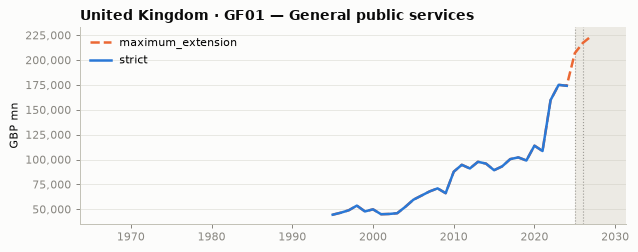

recipe:   1995-2024: anchor outturn (ONS_ESA_T11, grade A)  ·  2025: forward stitch (EC_AMECO, grade D)
          ·  2026-2027: proxy forecast (EC_AMECO, grade D)
outturn:  1995-2025
strict:   NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. §7.9: GF01
          total has no direct forecast source; strict ends at the last actual — maximum_extension
          carries the mandated GF01_7-growth proxy (grade D, coverage measured, residual_method
          recorded; D-S4-002)
maximum:  projects to 2027 — [no_official_forecast] §7.9: GF01 total has no direct forecast source;
          strict ends at the last actual — maximum_extension carries the mandated GF01_7-growth proxy
          (grade D, coverage measured, residual_method recorded; D-S4-002)


In [3]:
chart("GBR", "GF01")

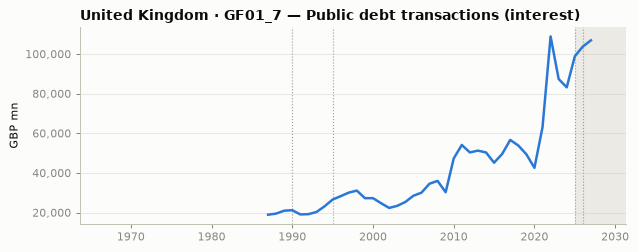

recipe:   1987-1989: backward stitch (EC_AMECO, grade B)  ·  1990-1994: backward stitch
          (ONS_PSF_INTEREST, grade B)  ·  1995-2024: anchor outturn (ONS_ESA_T11, grade A)  ·  2025:
          forward stitch (EC_AMECO, grade B)  ·  2026-2027: official forecast (EC_AMECO, grade B)
outturn:  1987-2025
strict:   projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)
maximum:  projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [4]:
chart("GBR", "GF01_7")

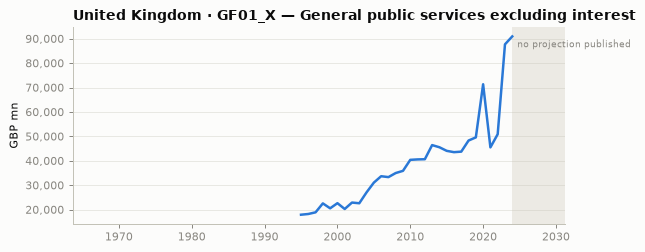

recipe:   1995-2024: derived by identity (ONS_ESA_T11, grade A)
outturn:  1995-2024
strict:   NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. never
          forecast by construction (D10); derived only
maximum:  NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. never
          forecast by construction (D10); derived only


In [5]:
chart("GBR", "GF01_X")

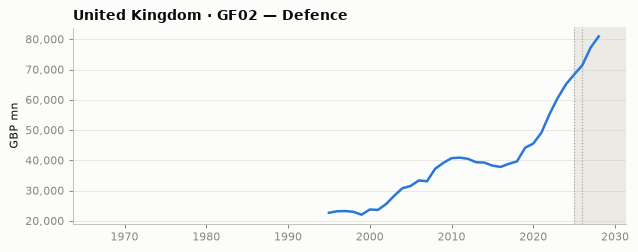

recipe:   1995-2024: anchor outturn (ONS_ESA_T11, grade A)  ·  2025: forward stitch (HMT_PESA, grade B)
          ·  2026-2028: official forecast (HMT_PESA, grade B)
outturn:  1995-2025
strict:   projects to 2028 — source horizon: HMT_PESA ends 2028 (V10)
maximum:  projects to 2028 — source horizon: HMT_PESA ends 2028 (V10)


In [6]:
chart("GBR", "GF02")

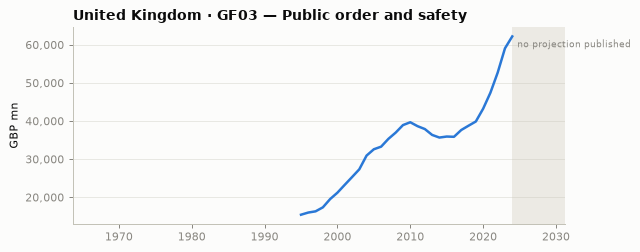

recipe:   1995-2024: anchor outturn (ONS_ESA_T11, grade A)
outturn:  1995-2024
strict:   NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
maximum:  NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual


In [7]:
chart("GBR", "GF03")

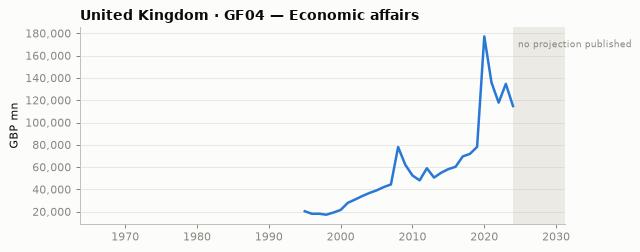

recipe:   1995-2024: anchor outturn (ONS_ESA_T11, grade A)
outturn:  1995-2024
strict:   NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
maximum:  NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual


In [8]:
chart("GBR", "GF04")

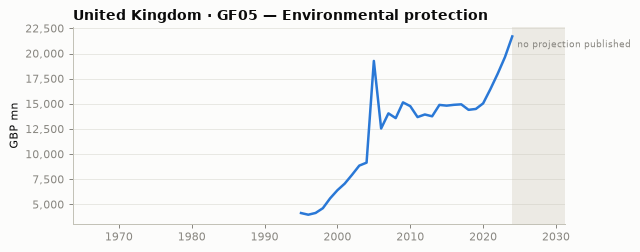

recipe:   1995-2024: anchor outturn (ONS_ESA_T11, grade A)
outturn:  1995-2024
strict:   NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
maximum:  NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual


In [9]:
chart("GBR", "GF05")

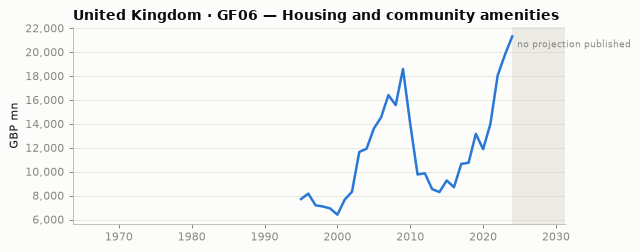

recipe:   1995-2024: anchor outturn (ONS_ESA_T11, grade A)
outturn:  1995-2024
strict:   NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
maximum:  NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual


In [10]:
chart("GBR", "GF06")

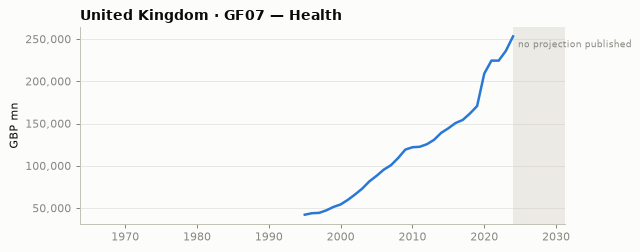

recipe:   1995-2024: anchor outturn (ONS_ESA_T11, grade A)
outturn:  1995-2024
strict:   NO PROJECTION — a forecast exists but the publication cannot be ingested. FRS July 2025 (hand-
          retrieved, D-S7-001) is thematic — pensions, balance sheet, climate — and carries no long-term
          health projection; the FRS edition with functional long-term projections (2024, or 2026 if
          published) is not in hand and obr.uk remains challenge-blocked (OQ-6); strict ends at the last
          actual
maximum:  NO PROJECTION — a forecast exists but the publication cannot be ingested. FRS July 2025 (hand-
          retrieved, D-S7-001) is thematic — pensions, balance sheet, climate — and carries no long-term
          health projection; the FRS edition with functional long-term projections (2024, or 2026 if
          published) is not in hand and obr.uk remains challenge-blocked (OQ-6); strict ends at the last
          actual


In [11]:
chart("GBR", "GF07")

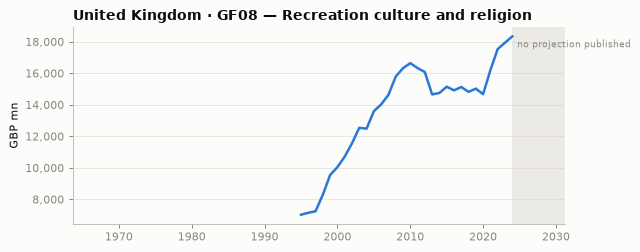

recipe:   1995-2024: anchor outturn (ONS_ESA_T11, grade A)
outturn:  1995-2024
strict:   NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
maximum:  NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual


In [12]:
chart("GBR", "GF08")

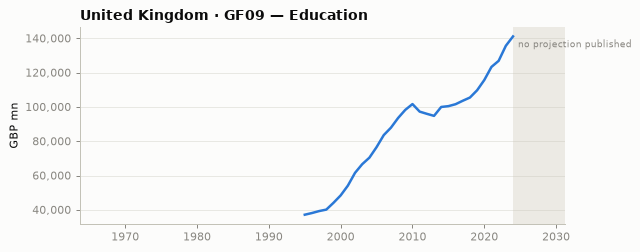

recipe:   1995-2024: anchor outturn (ONS_ESA_T11, grade A)
outturn:  1995-2024
strict:   NO PROJECTION — a forecast exists but the publication cannot be ingested. as GF07: no
          education long-term projection in the FRS July 2025 edition in hand (OQ-6); strict ends at the
          last actual
maximum:  NO PROJECTION — a forecast exists but the publication cannot be ingested. as GF07: no
          education long-term projection in the FRS July 2025 edition in hand (OQ-6); strict ends at the
          last actual


In [13]:
chart("GBR", "GF09")

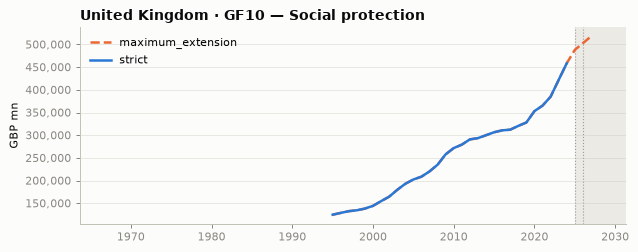

recipe:   1995-2024: anchor outturn (ONS_ESA_T11, grade A)  ·  2025: forward stitch (EC_AMECO, grade C)
          ·  2026-2027: proxy forecast (EC_AMECO, grade C)
outturn:  1995-2025
strict:   NO PROJECTION — the only candidate covers too little of the line to enter strict.
          maximum_extension carries the AMECO D.62 dominant-component proxy to 2027 (grade C, §7.8); the
          EFO welfare-spending series was measured as a longer C-band candidate but its table starts at
          FY 2024-25, leaving no year in common with the GG anchor to measure §9.2 coverage on —
          recorded, not applied (D-S7-003)
maximum:  projects to 2027 — [grade_below_strict] maximum_extension carries the AMECO D.62 dominant-
          component proxy to 2027 (grade C, §7.8); the EFO welfare-spending series was measured as a
          longer C-band candidate but its table starts at FY 2024-25, leaving no year in common with the
          GG anchor to measure §9.2 coverage on — recorded, not appli

In [14]:
chart("GBR", "GF10")

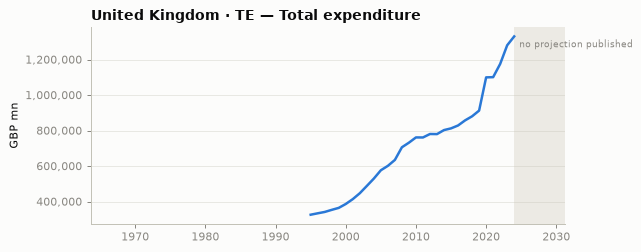

recipe:   1995-2024: anchor outturn (ONS_ESA_T11, grade A)
outturn:  1995-2024
strict:   NO PROJECTION — a total, deliberately not given a forecast path of its own. totals are
          envelopes (§6.1, D4): the envelope constrains V15 but is not published as a stitched TE path
maximum:  NO PROJECTION — a total, deliberately not given a forecast path of its own. totals are
          envelopes (§6.1, D4): the envelope constrains V15 but is not published as a stitched TE path


In [15]:
chart("GBR", "TE")

## 1.2 Revenue — ESA

Ten revenue types from VAT through to other transfers receivable, and total revenue.

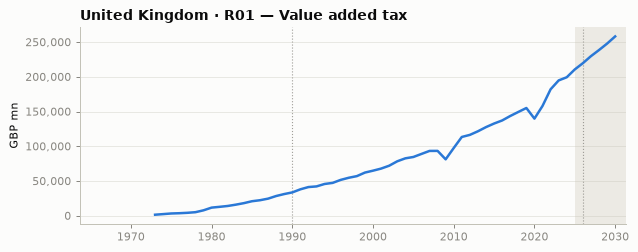

recipe:   1973-1989: backward stitch (OECD_RS, grade B)  ·  1990-2025: anchor outturn (ONS_GG_RECEIPTS,
          grade A)  ·  2026-2030: composite forecast (OBR_EFO_LATEST, grade B)
outturn:  1973-2025
strict:   projects to 2030 — source horizon: OBR_EFO_LATEST ends 2030 (V10)
maximum:  projects to 2030 — source horizon: OBR_EFO_LATEST ends 2030 (V10)


In [16]:
chart("GBR", "R01")

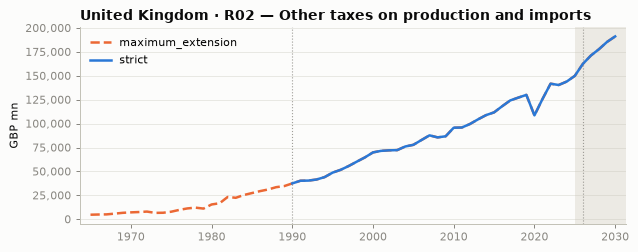

recipe:   1965-1989: backward stitch (OECD_RS, grade C)  ·  1990-2025: derived by identity
          (ONS_GG_RECEIPTS, grade A)  ·  2026-2030: composite forecast (OBR_EFO_LATEST, grade B)
outturn:  1965-2025
strict:   projects to 2030 — source horizon: OBR_EFO_LATEST ends 2030 (V10)
maximum:  projects to 2030 — source horizon: OBR_EFO_LATEST ends 2030 (V10)


In [17]:
chart("GBR", "R02")

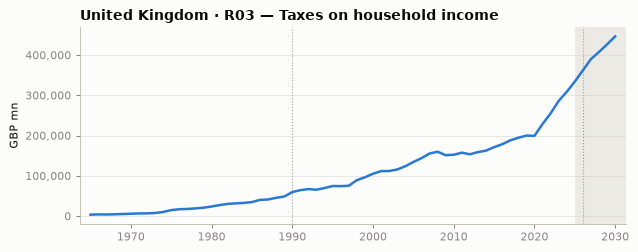

recipe:   1965-1989: backward stitch (OECD_RS, grade B)  ·  1990-2025: anchor outturn (ONS_GG_RECEIPTS,
          grade A)  ·  2026-2030: composite forecast (OBR_EFO_LATEST, grade B)
outturn:  1965-2025
strict:   projects to 2030 — source horizon: OBR_EFO_LATEST ends 2030 (V10)
maximum:  projects to 2030 — source horizon: OBR_EFO_LATEST ends 2030 (V10)


In [18]:
chart("GBR", "R03")

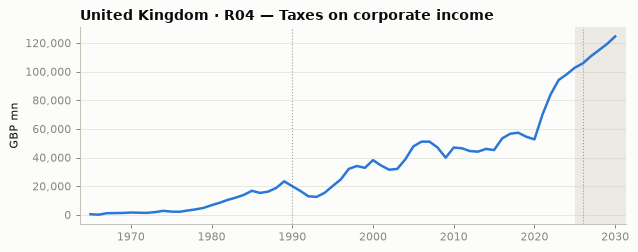

recipe:   1965-1989: backward stitch (OECD_RS, grade B)  ·  1990-2025: anchor outturn (ONS_GG_RECEIPTS,
          grade A)  ·  2026-2030: composite forecast (OBR_EFO_LATEST, grade B)
outturn:  1965-2025
strict:   projects to 2030 — source horizon: OBR_EFO_LATEST ends 2030 (V10)
maximum:  projects to 2030 — source horizon: OBR_EFO_LATEST ends 2030 (V10)


In [19]:
chart("GBR", "R04")

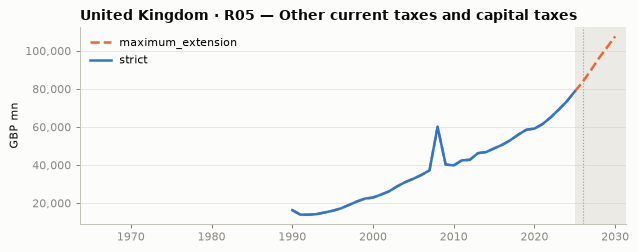

recipe:   1990-2025: derived by identity (ONS_GG_RECEIPTS, grade A)  ·  2026-2030: composite forecast
          (OBR_EFO_LATEST, grade C)
outturn:  1990-2025
strict:   NO PROJECTION — the only candidate covers too little of the line to enter strict. OBR council
          tax + inheritance tax + licence fee composite measured at 79% of the line (C) — applied in
          maximum_extension to 2030; the remaining D.59/D.91 items have no forecast anywhere (D7 lists
          R05 as partial); AMECO UTKG (11%, D) recorded, not applied
maximum:  projects to 2030 — [grade_below_strict] OBR council tax + inheritance tax + licence fee
          composite measured at 79% of the line (C) — applied in maximum_extension to 2030; the
          remaining D.59/D.91 items have no forecast anywhere (D7 lists R05 as partial); AMECO UTKG
          (11%, D) recorded, not applied


In [20]:
chart("GBR", "R05")

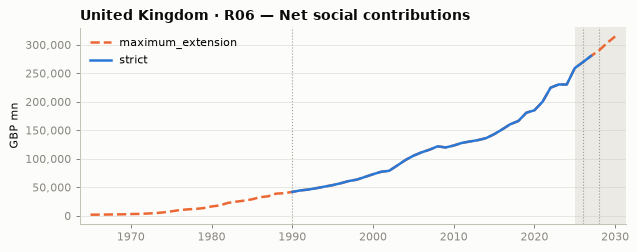

recipe:   1965-1989: backward stitch (OECD_RS, grade C)  ·  1990-2025: anchor outturn (ONS_GG_RECEIPTS,
          grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)  ·  2028-2030: official forecast
          (OBR_EFO_LATEST, grade C)
outturn:  1965-2025
strict:   projects to 2027 — source horizon: OBR_EFO_LATEST ends 2030 (V10)
maximum:  projects to 2030 — source horizon: OBR_EFO_LATEST ends 2030 (V10)


In [21]:
chart("GBR", "R06")

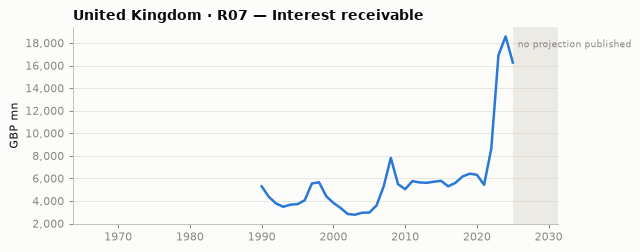

recipe:   1990-2025: anchor outturn (ONS_GG_RECEIPTS, grade A)
outturn:  1990-2025
strict:   NO PROJECTION — the candidate source has no ESA-complete machine-readable series. no usable GG
          interest-receivable forecast: AMECO has no D.41 resources series (UYVG is subsidies); DSM
          publishes payable interest only; the OBR 'PS interest and dividend receipts' candidate
          (D-S7-003) mixes dividends and the PS perimeter into the line and measures outside every band
          — recorded, not applied; NI/PB forecast ledger therefore stays empty (§4.3)
maximum:  NO PROJECTION — the candidate source has no ESA-complete machine-readable series. no usable GG
          interest-receivable forecast: AMECO has no D.41 resources series (UYVG is subsidies); DSM
          publishes payable interest only; the OBR 'PS interest and dividend receipts' candidate
          (D-S7-003) mixes dividends and the PS perimeter into the line and measures outside every band
          — recorde

In [22]:
chart("GBR", "R07")

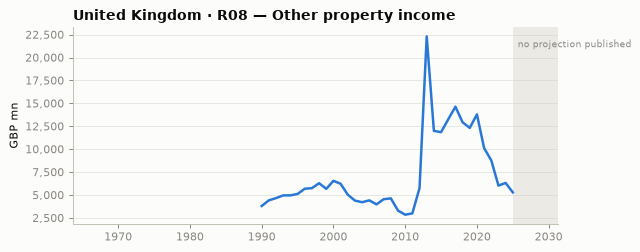

recipe:   1990-2025: derived by identity (ONS_GG_RECEIPTS, grade A)
outturn:  1990-2025
strict:   NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
maximum:  NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual


In [23]:
chart("GBR", "R08")

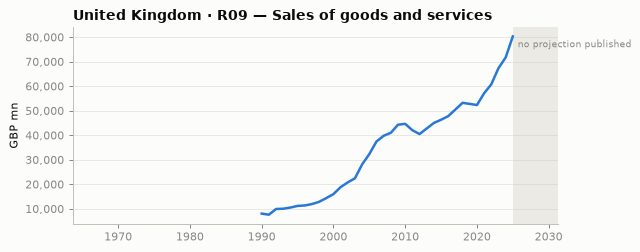

recipe:   1990-2025: derived by identity (ONS_GG_RECEIPTS, grade A)
outturn:  1990-2025
strict:   NO PROJECTION — the candidate source has no ESA-complete machine-readable series. AMECO
          publishes no UK UTOG/UROG history (OQ-4 pattern) and the EFO receipts tables do not separate
          P.11+P.12+P.131 sales (GOS and 'other receipts' are different concepts) — no measurable
          composite
maximum:  NO PROJECTION — the candidate source has no ESA-complete machine-readable series. AMECO
          publishes no UK UTOG/UROG history (OQ-4 pattern) and the EFO receipts tables do not separate
          P.11+P.12+P.131 sales (GOS and 'other receipts' are different concepts) — no measurable
          composite


In [24]:
chart("GBR", "R09")

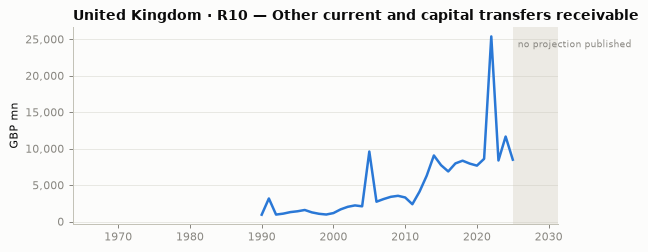

recipe:   1990-2025: derived by identity (ONS_GG_RECEIPTS, grade A)
outturn:  1990-2025
strict:   NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
maximum:  NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual


In [25]:
chart("GBR", "R10")

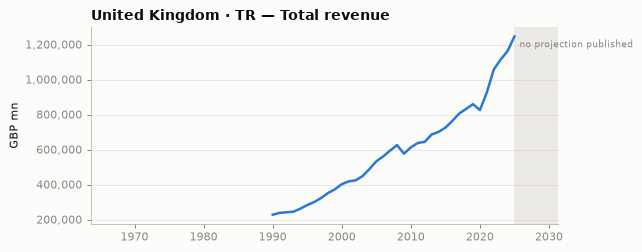

recipe:   1990-2025: anchor outturn (ONS_GG_RECEIPTS, grade A)
outturn:  1990-2025
strict:   NO PROJECTION — a total, deliberately not given a forecast path of its own. totals are
          envelopes (§6.1, D4): used in V15 only
maximum:  NO PROJECTION — a total, deliberately not given a forecast path of its own. totals are
          envelopes (§6.1, D4): used in V15 only


In [26]:
chart("GBR", "TR")

## 1.3 Balance ledger

Outturn years only, single line each — the two variants are identical here. TR and TE are the balance anchor's own totals, not sums of the lines above.

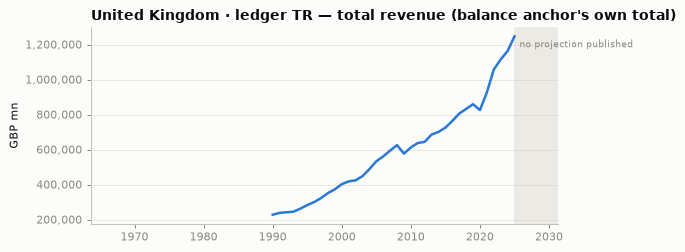

outturn:  1990-2025, source ONS_GG_RECEIPTS
forecast: NO PROJECTION — the ledger is outturn-only by design. Building it forward would mean summing
          lines whose forecast coverage is partial, which would misstate the totals; the forecast-side
          comparison lives in section 4 instead, where the coverage gap is explicit.


In [27]:
ledger_chart("GBR", "TR")

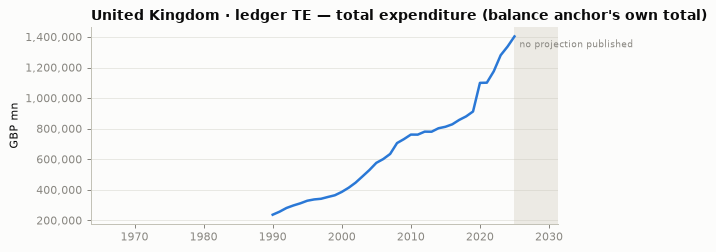

outturn:  1990-2025, source ONS_GG_RECEIPTS
forecast: NO PROJECTION — the ledger is outturn-only by design. Building it forward would mean summing
          lines whose forecast coverage is partial, which would misstate the totals; the forecast-side
          comparison lives in section 4 instead, where the coverage gap is explicit.


In [28]:
ledger_chart("GBR", "TE")

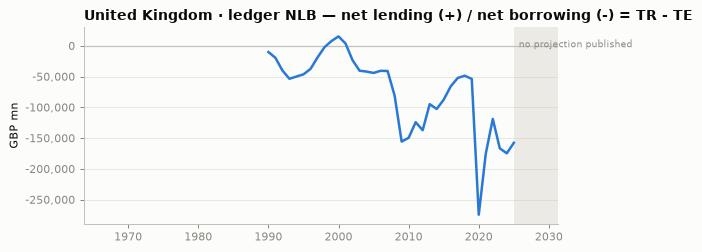

outturn:  1990-2025, source ONS_GG_RECEIPTS
forecast: NO PROJECTION — the ledger is outturn-only by design. Building it forward would mean summing
          lines whose forecast coverage is partial, which would misstate the totals; the forecast-side
          comparison lives in section 4 instead, where the coverage gap is explicit.


In [29]:
ledger_chart("GBR", "NLB")

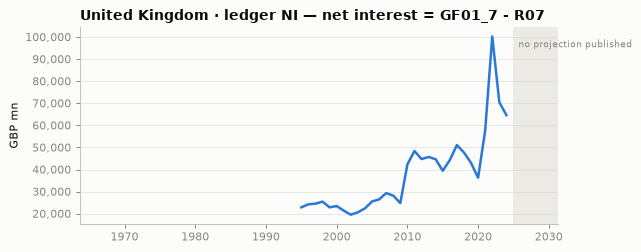

outturn:  1990-2025, source ONS_GG_RECEIPTS; no value for [1990, 1991, 1992, 1993, 1994, 2025]
forecast: NO PROJECTION — the ledger is outturn-only by design. Building it forward would mean summing
          lines whose forecast coverage is partial, which would misstate the totals; the forecast-side
          comparison lives in section 4 instead, where the coverage gap is explicit.


In [30]:
ledger_chart("GBR", "NI")

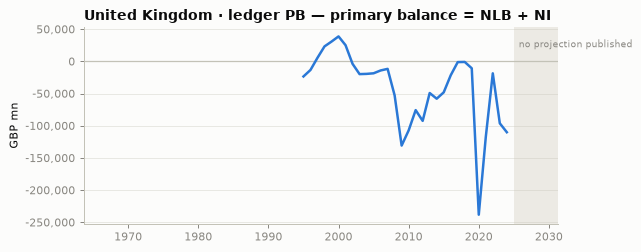

outturn:  1990-2025, source ONS_GG_RECEIPTS; no value for [1990, 1991, 1992, 1993, 1994, 2025]
forecast: NO PROJECTION — the ledger is outturn-only by design. Building it forward would mean summing
          lines whose forecast coverage is partial, which would misstate the totals; the forecast-side
          comparison lives in section 4 instead, where the coverage gap is explicit.


In [31]:
ledger_chart("GBR", "PB")

---

# 2. France (FRA)

## 2.1 Expenditure — COFOG

Ten Level I functions, the Level II interest line `GF01_7`, the identity `GF01_X = GF01 − GF01_7`, and total expenditure.

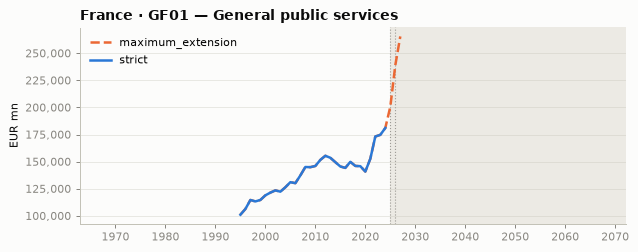

recipe:   1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)  ·  2025: forward stitch (EC_AMECO,
          grade D)  ·  2026-2027: proxy forecast (EC_AMECO, grade D)
outturn:  1995-2025
strict:   NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. §7.9: GF01
          total has no direct forecast source; strict ends at the last actual — maximum_extension
          carries the mandated GF01_7-growth proxy (grade D, coverage measured, residual_method
          recorded; D-S4-002)
maximum:  projects to 2027 — [no_official_forecast] §7.9: GF01 total has no direct forecast source;
          strict ends at the last actual — maximum_extension carries the mandated GF01_7-growth proxy
          (grade D, coverage measured, residual_method recorded; D-S4-002)


In [32]:
chart("FRA", "GF01")

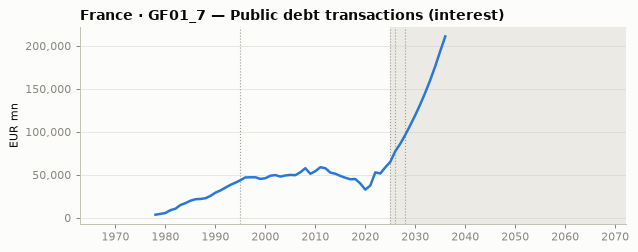

recipe:   1978-1994: backward stitch (EC_AMECO, grade B)  ·  1995-2024: anchor outturn
          (EUROSTAT_GOV10A_EXP, grade A)  ·  2025: forward stitch (EC_AMECO, grade B)  ·  2026-2027:
          official forecast (EC_AMECO, grade B)  ·  2028-2036: official forecast (EC_DSM, grade B)
outturn:  1978-2025
strict:   projects to 2036 — source horizon: EC_DSM ends 2036 (V10)
maximum:  projects to 2036 — source horizon: EC_DSM ends 2036 (V10)


In [33]:
chart("FRA", "GF01_7")

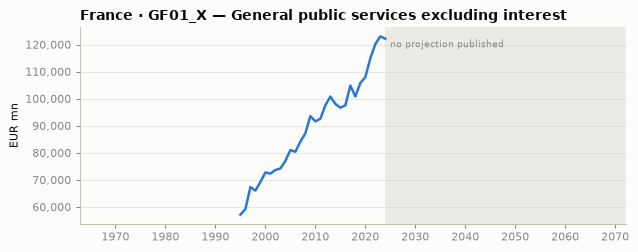

recipe:   1995-2024: derived by identity (EUROSTAT_GOV10A_EXP, grade A)
outturn:  1995-2024
strict:   NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. never
          forecast by construction (D10); derived only
maximum:  NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. never
          forecast by construction (D10); derived only


In [34]:
chart("FRA", "GF01_X")

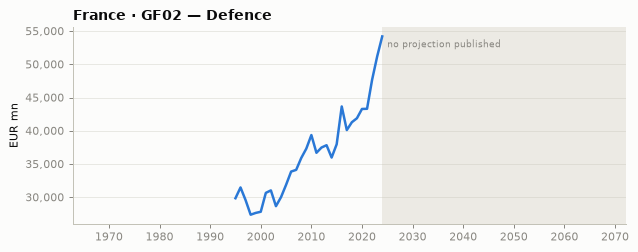

recipe:   1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)
outturn:  1995-2024
strict:   NO PROJECTION — a forecast exists but the publication cannot be ingested. identified source
          FRA_LPM_2030 (military programming law) is PDF-only; §11.4 manual ingestion requires an
          independent second keying unavailable to a single-agent session (OQ-5 precedent) — OQ-6;
          strict ends at the last actual
maximum:  NO PROJECTION — a forecast exists but the publication cannot be ingested. identified source
          FRA_LPM_2030 (military programming law) is PDF-only; §11.4 manual ingestion requires an
          independent second keying unavailable to a single-agent session (OQ-5 precedent) — OQ-6;
          strict ends at the last actual


In [35]:
chart("FRA", "GF02")

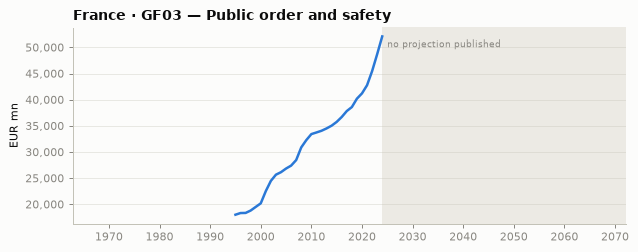

recipe:   1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)
outturn:  1995-2024
strict:   NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
maximum:  NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual


In [36]:
chart("FRA", "GF03")

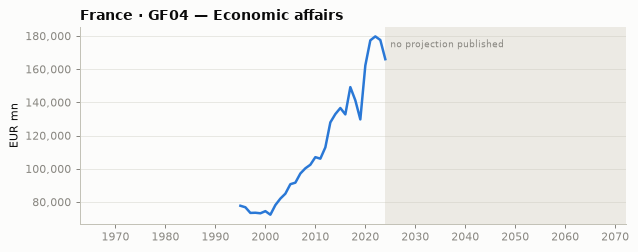

recipe:   1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)
outturn:  1995-2024
strict:   NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
maximum:  NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual


In [37]:
chart("FRA", "GF04")

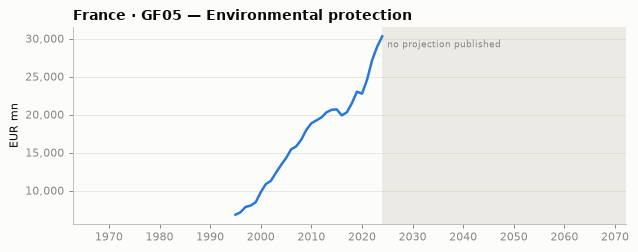

recipe:   1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)
outturn:  1995-2024
strict:   NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
maximum:  NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual


In [38]:
chart("FRA", "GF05")

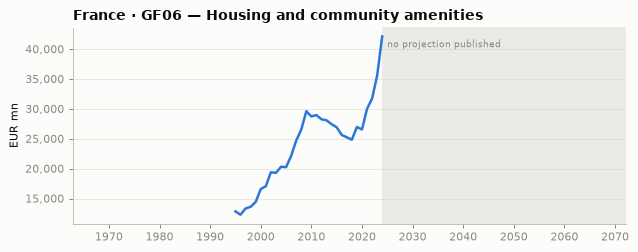

recipe:   1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)
outturn:  1995-2024
strict:   NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
maximum:  NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual


In [39]:
chart("FRA", "GF06")

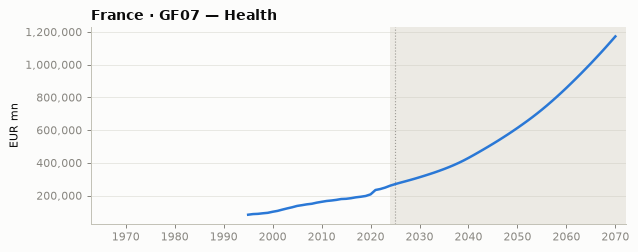

recipe:   1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)  ·  2025-2070: official forecast
          (EC_AGEING_2024, grade B)
outturn:  1995-2024
strict:   projects to 2070 — source horizon: EC_AGEING_2024 ends 2070 (V10)
maximum:  projects to 2070 — source horizon: EC_AGEING_2024 ends 2070 (V10)


In [40]:
chart("FRA", "GF07")

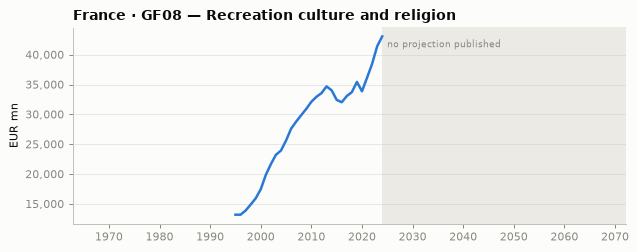

recipe:   1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)
outturn:  1995-2024
strict:   NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
maximum:  NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual


In [41]:
chart("FRA", "GF08")

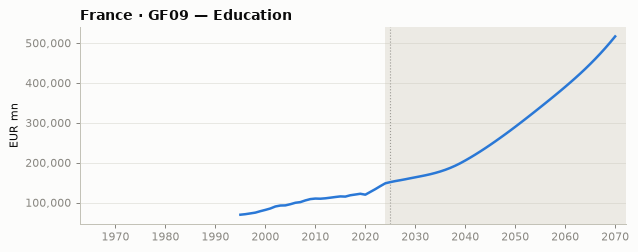

recipe:   1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)  ·  2025-2070: official forecast
          (EC_AGEING_2024, grade B)
outturn:  1995-2024
strict:   projects to 2070 — source horizon: EC_AGEING_2024 ends 2070 (V10)
maximum:  projects to 2070 — source horizon: EC_AGEING_2024 ends 2070 (V10)


In [42]:
chart("FRA", "GF09")

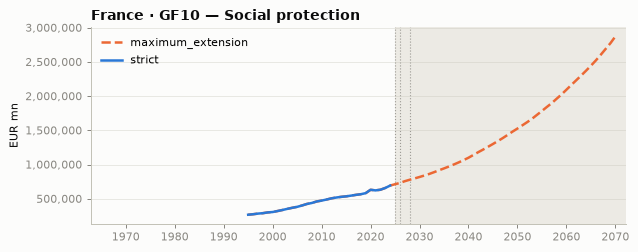

recipe:   1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)  ·  2025: forward stitch (EC_AMECO,
          grade C)  ·  2026-2027: proxy forecast (EC_AMECO, grade C)  ·  2028-2070: composite forecast
          (EC_AGEING_2024, grade C)
outturn:  1995-2025
strict:   NO PROJECTION — the only candidate covers too little of the line to enter strict. AR
          pensions+LTC composite measured at 69% of GF10 (grade C: no official projection of
          family/housing/unemployment components) — no strict forecast; maximum_extension chains the
          AMECO D.62 proxy (to 2027) into the AR composite (to 2070) per D12, overlap divergence under
          the V16 threshold
maximum:  projects to 2070 — [grade_below_strict] AR pensions+LTC composite measured at 69% of GF10
          (grade C: no official projection of family/housing/unemployment components) — no strict
          forecast; maximum_extension chains the AMECO D.62 proxy (to 2027) into the AR composite (to
          2070) pe

In [43]:
chart("FRA", "GF10")

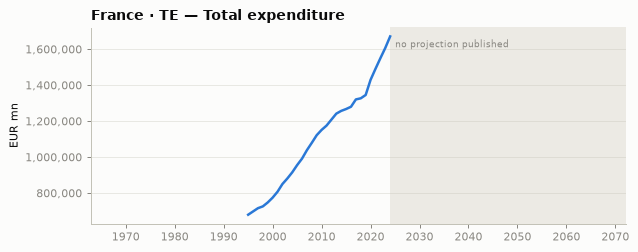

recipe:   1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)
outturn:  1995-2024
strict:   NO PROJECTION — a total, deliberately not given a forecast path of its own. totals are
          envelopes (§6.1, D4): the envelope constrains V15 but is not published as a stitched TE path
maximum:  NO PROJECTION — a total, deliberately not given a forecast path of its own. totals are
          envelopes (§6.1, D4): the envelope constrains V15 but is not published as a stitched TE path


In [44]:
chart("FRA", "TE")

## 2.2 Revenue — ESA

Ten revenue types from VAT through to other transfers receivable, and total revenue.

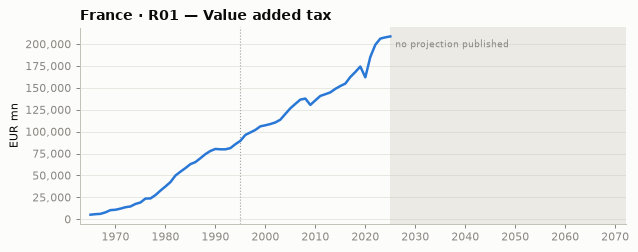

recipe:   1965-1994: backward stitch (OECD_RS, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1965-2025
strict:   NO PROJECTION — a forecast exists but the publication cannot be ingested. identified source
          FRA_LPFP_PSTAB (prélèvements obligatoires) is PDF-only; §11.4 manual ingestion requires an
          independent second keying unavailable to a single-agent session (OQ-5 precedent) — OQ-6;
          strict ends at the last actual
maximum:  NO PROJECTION — a forecast exists but the publication cannot be ingested. identified source
          FRA_LPFP_PSTAB (prélèvements obligatoires) is PDF-only; §11.4 manual ingestion requires an
          independent second keying unavailable to a single-agent session (OQ-5 precedent) — OQ-6;
          strict ends at the last actual


In [45]:
chart("FRA", "R01")

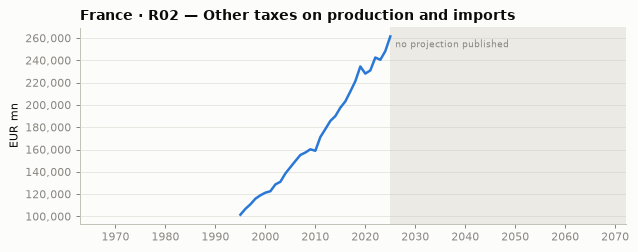

recipe:   1995-2025: derived by identity (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1995-2025
strict:   NO PROJECTION — a forecast exists but the publication cannot be ingested. identified source
          FRA_LPFP_PSTAB is PDF-only; §11.4 manual ingestion requires an independent second keying
          unavailable to a single-agent session (OQ-5 precedent) — OQ-6; strict ends at the last actual
maximum:  NO PROJECTION — a forecast exists but the publication cannot be ingested. identified source
          FRA_LPFP_PSTAB is PDF-only; §11.4 manual ingestion requires an independent second keying
          unavailable to a single-agent session (OQ-5 precedent) — OQ-6; strict ends at the last actual


In [46]:
chart("FRA", "R02")

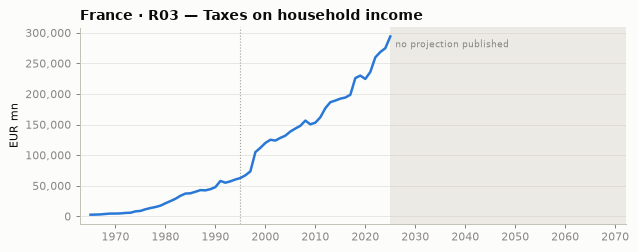

recipe:   1965-1994: backward stitch (OECD_RS, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1965-2025
strict:   NO PROJECTION — a forecast exists but the publication cannot be ingested. identified source
          FRA_LPFP_PSTAB is PDF-only; §11.4 manual ingestion requires an independent second keying
          unavailable to a single-agent session (OQ-5 precedent) — OQ-6; strict ends at the last actual
maximum:  NO PROJECTION — a forecast exists but the publication cannot be ingested. identified source
          FRA_LPFP_PSTAB is PDF-only; §11.4 manual ingestion requires an independent second keying
          unavailable to a single-agent session (OQ-5 precedent) — OQ-6; strict ends at the last actual


In [47]:
chart("FRA", "R03")

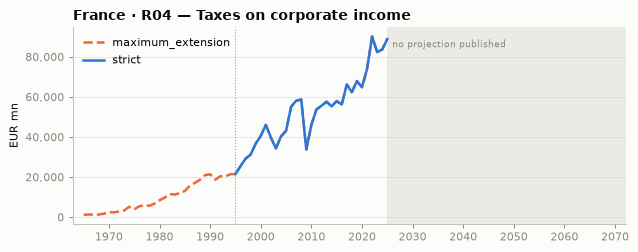

recipe:   1965-1994: backward stitch (OECD_RS, grade C)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1965-2025
strict:   NO PROJECTION — a forecast exists but the publication cannot be ingested. identified source
          FRA_LPFP_PSTAB is PDF-only; §11.4 manual ingestion requires an independent second keying
          unavailable to a single-agent session (OQ-5 precedent) — OQ-6; strict ends at the last actual
maximum:  NO PROJECTION — a forecast exists but the publication cannot be ingested. identified source
          FRA_LPFP_PSTAB is PDF-only; §11.4 manual ingestion requires an independent second keying
          unavailable to a single-agent session (OQ-5 precedent) — OQ-6; strict ends at the last actual


In [48]:
chart("FRA", "R04")

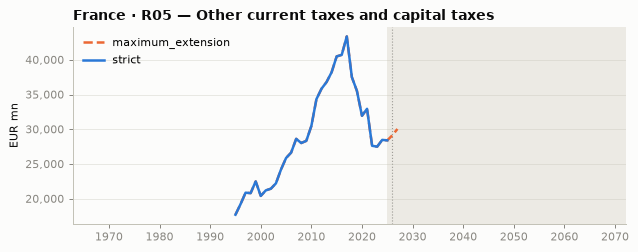

recipe:   1995-2025: derived by identity (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: proxy forecast
          (EC_AMECO, grade C)
outturn:  1995-2025
strict:   NO PROJECTION — the only candidate covers too little of the line to enter strict. AMECO UTKG
          covers 76% of the line (grade C) — no strict forecast; applied in maximum_extension as a §7.8
          single-component proxy to 2027; D7 lists R05 as partial
maximum:  projects to 2027 — [grade_below_strict] AMECO UTKG covers 76% of the line (grade C) — no
          strict forecast; applied in maximum_extension as a §7.8 single-component proxy to 2027; D7
          lists R05 as partial


In [49]:
chart("FRA", "R05")

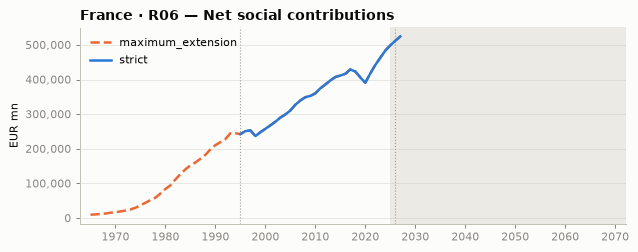

recipe:   1965-1994: backward stitch (OECD_RS, grade C)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)
outturn:  1965-2025
strict:   projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)
maximum:  projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [50]:
chart("FRA", "R06")

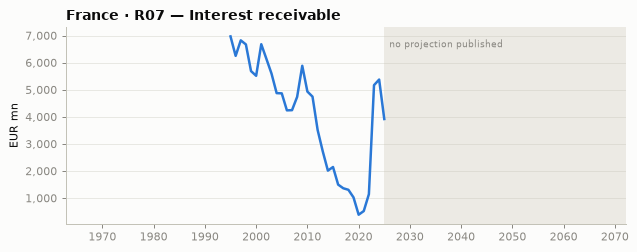

recipe:   1995-2025: anchor outturn (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1995-2025
strict:   NO PROJECTION — the candidate source has no ESA-complete machine-readable series. no usable GG
          interest-receivable forecast: AMECO has no D.41 resources series (UYVG is subsidies); DSM
          publishes payable interest only; the OBR 'PS interest and dividend receipts' candidate
          (D-S7-003) mixes dividends and the PS perimeter into the line and measures outside every band
          — recorded, not applied; NI/PB forecast ledger therefore stays empty (§4.3)
maximum:  NO PROJECTION — the candidate source has no ESA-complete machine-readable series. no usable GG
          interest-receivable forecast: AMECO has no D.41 resources series (UYVG is subsidies); DSM
          publishes payable interest only; the OBR 'PS interest and dividend receipts' candidate
          (D-S7-003) mixes dividends and the PS perimeter into the line and measures outside every band
          — re

In [51]:
chart("FRA", "R07")

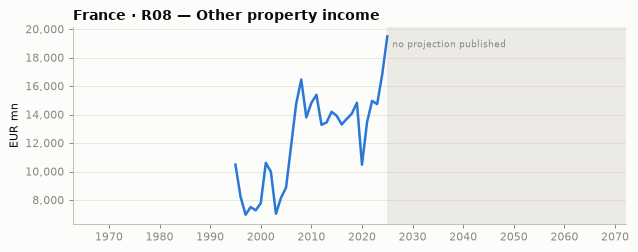

recipe:   1995-2025: derived by identity (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1995-2025
strict:   NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
maximum:  NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual


In [52]:
chart("FRA", "R08")

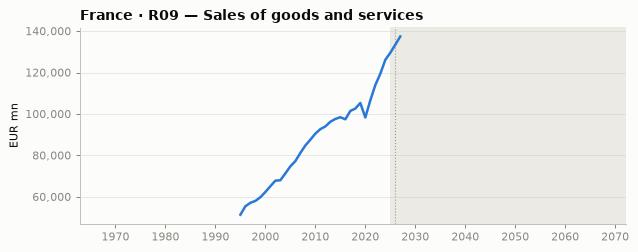

recipe:   1995-2025: anchor outturn (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: composite forecast
          (EC_AMECO, grade B)
outturn:  1995-2025
strict:   projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)
maximum:  projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [53]:
chart("FRA", "R09")

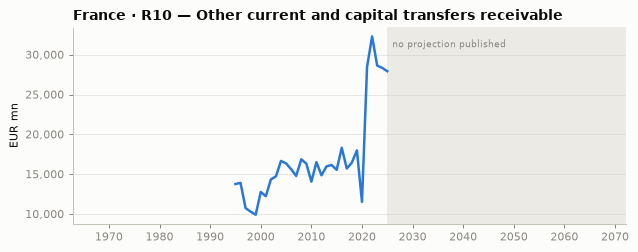

recipe:   1995-2025: derived by identity (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1995-2025
strict:   NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
maximum:  NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual


In [54]:
chart("FRA", "R10")

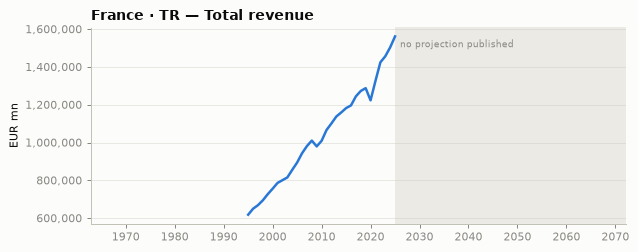

recipe:   1995-2025: anchor outturn (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1995-2025
strict:   NO PROJECTION — a total, deliberately not given a forecast path of its own. totals are
          envelopes (§6.1, D4): used in V15 only
maximum:  NO PROJECTION — a total, deliberately not given a forecast path of its own. totals are
          envelopes (§6.1, D4): used in V15 only


In [55]:
chart("FRA", "TR")

## 2.3 Balance ledger

Outturn years only, single line each — the two variants are identical here. TR and TE are the balance anchor's own totals, not sums of the lines above.

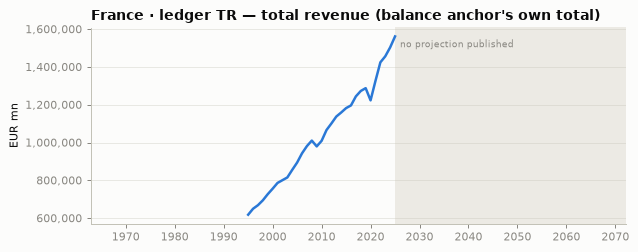

outturn:  1995-2025, source EUROSTAT_GOV10A_MAIN
forecast: NO PROJECTION — the ledger is outturn-only by design. Building it forward would mean summing
          lines whose forecast coverage is partial, which would misstate the totals; the forecast-side
          comparison lives in section 4 instead, where the coverage gap is explicit.


In [56]:
ledger_chart("FRA", "TR")

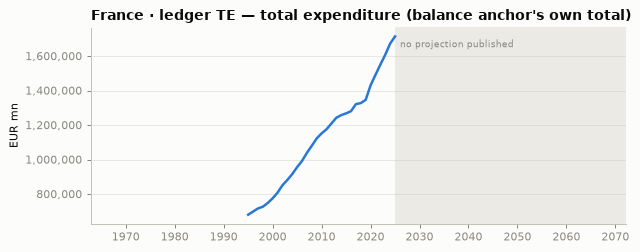

outturn:  1995-2025, source EUROSTAT_GOV10A_MAIN
forecast: NO PROJECTION — the ledger is outturn-only by design. Building it forward would mean summing
          lines whose forecast coverage is partial, which would misstate the totals; the forecast-side
          comparison lives in section 4 instead, where the coverage gap is explicit.


In [57]:
ledger_chart("FRA", "TE")

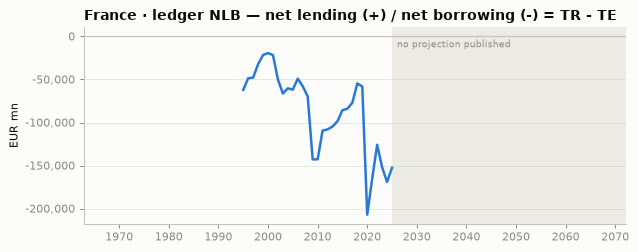

outturn:  1995-2025, source EUROSTAT_GOV10A_MAIN
forecast: NO PROJECTION — the ledger is outturn-only by design. Building it forward would mean summing
          lines whose forecast coverage is partial, which would misstate the totals; the forecast-side
          comparison lives in section 4 instead, where the coverage gap is explicit.


In [58]:
ledger_chart("FRA", "NLB")

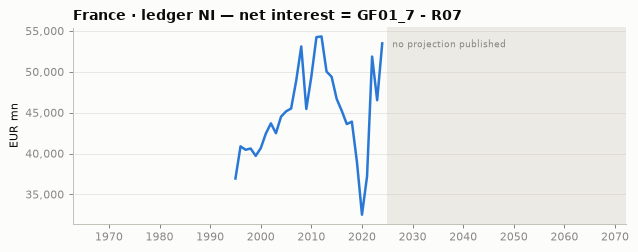

outturn:  1995-2025, source EUROSTAT_GOV10A_MAIN; no value for [2025]
forecast: NO PROJECTION — the ledger is outturn-only by design. Building it forward would mean summing
          lines whose forecast coverage is partial, which would misstate the totals; the forecast-side
          comparison lives in section 4 instead, where the coverage gap is explicit.


In [59]:
ledger_chart("FRA", "NI")

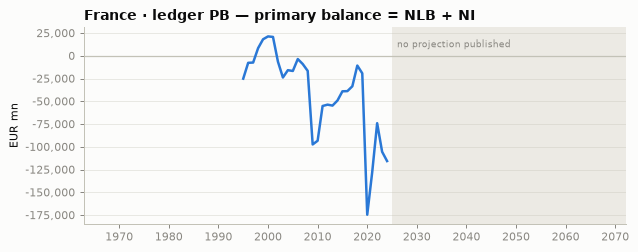

outturn:  1995-2025, source EUROSTAT_GOV10A_MAIN; no value for [2025]
forecast: NO PROJECTION — the ledger is outturn-only by design. Building it forward would mean summing
          lines whose forecast coverage is partial, which would misstate the totals; the forecast-side
          comparison lives in section 4 instead, where the coverage gap is explicit.


In [60]:
ledger_chart("FRA", "PB")

---

# 3. Germany (DEU)

## 3.1 Expenditure — COFOG

Ten Level I functions, the Level II interest line `GF01_7`, the identity `GF01_X = GF01 − GF01_7`, and total expenditure.

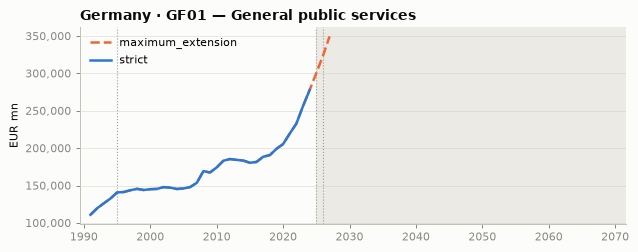

recipe:   1991-1994: backward stitch (IMF_GFS, grade B)  ·  1995-2024: anchor outturn
          (EUROSTAT_GOV10A_EXP, grade A)  ·  2025: forward stitch (EC_AMECO, grade D)  ·  2026-2027:
          proxy forecast (EC_AMECO, grade D)
outturn:  1991-2025
strict:   NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. §7.9: GF01
          total has no direct forecast source; strict ends at the last actual — maximum_extension
          carries the mandated GF01_7-growth proxy (grade D, coverage measured, residual_method
          recorded; D-S4-002)
maximum:  projects to 2027 — [no_official_forecast] §7.9: GF01 total has no direct forecast source;
          strict ends at the last actual — maximum_extension carries the mandated GF01_7-growth proxy
          (grade D, coverage measured, residual_method recorded; D-S4-002)


In [61]:
chart("DEU", "GF01")

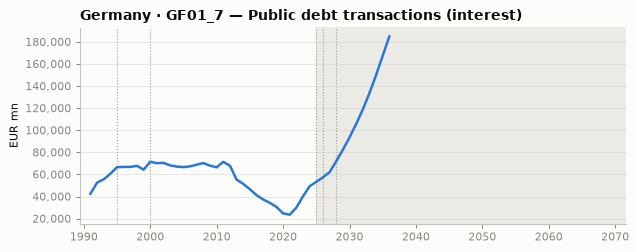

recipe:   1991-1994: backward stitch (EC_AMECO, grade B)  ·  1995-1999: anchor outturn on the D10
          fallback concept (EUROSTAT_GOV10A_EXP, grade B)  ·  2000-2024: anchor outturn
          (EUROSTAT_GOV10A_EXP, grade A)  ·  2025: forward stitch (EC_AMECO, grade B)  ·  2026-2027:
          official forecast (EC_AMECO, grade B)  ·  2028-2036: official forecast (EC_DSM, grade B)
outturn:  1991-2025
strict:   projects to 2036 — source horizon: EC_DSM ends 2036 (V10)
maximum:  projects to 2036 — source horizon: EC_DSM ends 2036 (V10)


In [62]:
chart("DEU", "GF01_7")

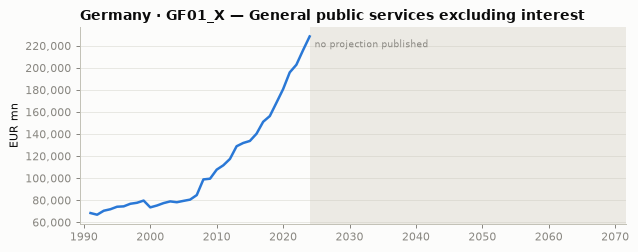

recipe:   1991-1999: derived by identity (EUROSTAT_GOV10A_EXP, grade B)  ·  2000-2024: derived by
          identity (EUROSTAT_GOV10A_EXP, grade A)
outturn:  1991-2024
strict:   NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. never
          forecast by construction (D10); derived only
maximum:  NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. never
          forecast by construction (D10); derived only


In [63]:
chart("DEU", "GF01_X")

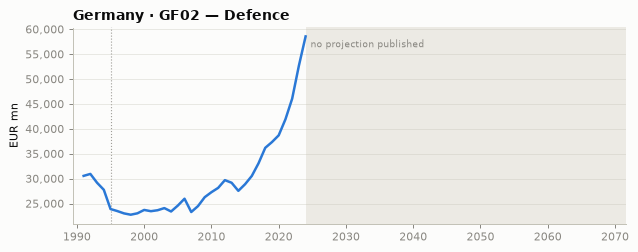

recipe:   1991-1994: backward stitch (IMF_GFS, grade B)  ·  1995-2024: anchor outturn
          (EUROSTAT_GOV10A_EXP, grade A)
outturn:  1991-2024
strict:   NO PROJECTION — a forecast exists but the publication cannot be ingested. identified source
          DEU_BMF_FINPLAN (Epl. 14 + Sondervermögen Bundeswehr) is PDF-only; §11.4 manual ingestion
          requires an independent second keying unavailable to a single-agent session (OQ-5 precedent) —
          OQ-6; strict ends at the last actual
maximum:  NO PROJECTION — a forecast exists but the publication cannot be ingested. identified source
          DEU_BMF_FINPLAN (Epl. 14 + Sondervermögen Bundeswehr) is PDF-only; §11.4 manual ingestion
          requires an independent second keying unavailable to a single-agent session (OQ-5 precedent) —
          OQ-6; strict ends at the last actual


In [64]:
chart("DEU", "GF02")

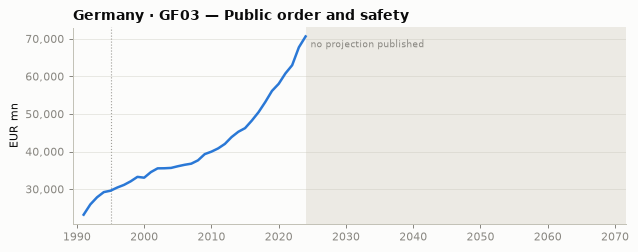

recipe:   1991-1994: backward stitch (IMF_GFS, grade B)  ·  1995-2024: anchor outturn
          (EUROSTAT_GOV10A_EXP, grade A)
outturn:  1991-2024
strict:   NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
maximum:  NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual


In [65]:
chart("DEU", "GF03")

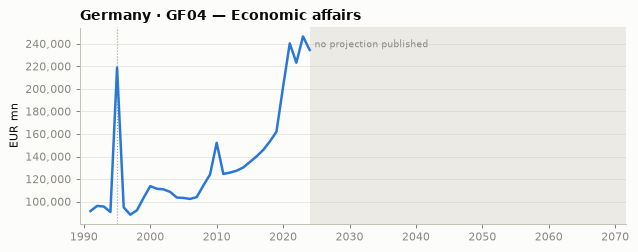

recipe:   1991-1994: backward stitch (IMF_GFS, grade B)  ·  1995-2024: anchor outturn
          (EUROSTAT_GOV10A_EXP, grade A)
outturn:  1991-2024
strict:   NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
maximum:  NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual


In [66]:
chart("DEU", "GF04")

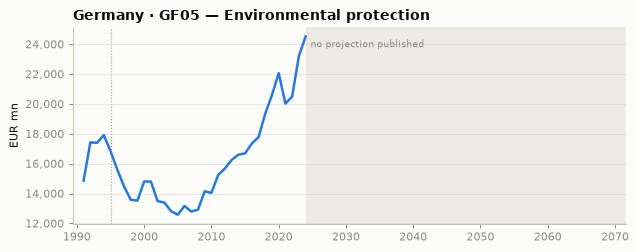

recipe:   1991-1994: backward stitch (IMF_GFS, grade B)  ·  1995-2024: anchor outturn
          (EUROSTAT_GOV10A_EXP, grade A)
outturn:  1991-2024
strict:   NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
maximum:  NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual


In [67]:
chart("DEU", "GF05")

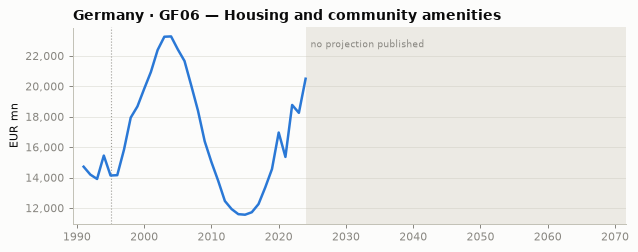

recipe:   1991-1994: backward stitch (IMF_GFS, grade B)  ·  1995-2024: anchor outturn
          (EUROSTAT_GOV10A_EXP, grade A)
outturn:  1991-2024
strict:   NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
maximum:  NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual


In [68]:
chart("DEU", "GF06")

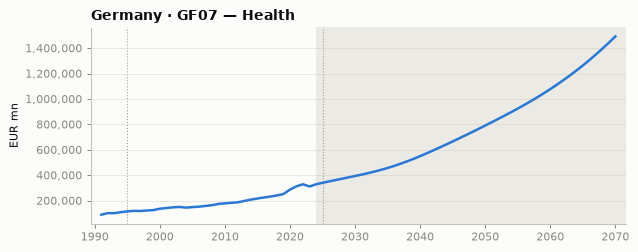

recipe:   1991-1994: backward stitch (IMF_GFS, grade B)  ·  1995-2024: anchor outturn
          (EUROSTAT_GOV10A_EXP, grade A)  ·  2025-2070: official forecast (EC_AGEING_2024, grade B)
outturn:  1991-2024
strict:   projects to 2070 — source horizon: EC_AGEING_2024 ends 2070 (V10)
maximum:  projects to 2070 — source horizon: EC_AGEING_2024 ends 2070 (V10)


In [69]:
chart("DEU", "GF07")

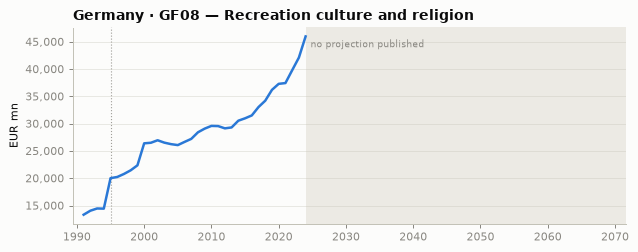

recipe:   1991-1994: backward stitch (IMF_GFS, grade B)  ·  1995-2024: anchor outturn
          (EUROSTAT_GOV10A_EXP, grade A)
outturn:  1991-2024
strict:   NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
maximum:  NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual


In [70]:
chart("DEU", "GF08")

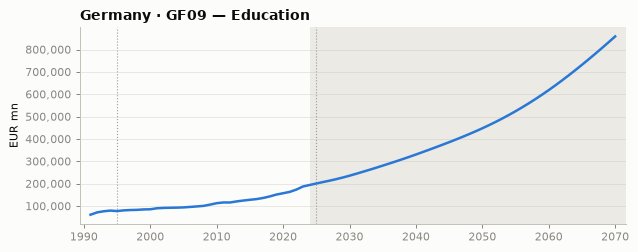

recipe:   1991-1994: backward stitch (IMF_GFS, grade B)  ·  1995-2024: anchor outturn
          (EUROSTAT_GOV10A_EXP, grade A)  ·  2025-2070: official forecast (EC_AGEING_2024, grade B)
outturn:  1991-2024
strict:   projects to 2070 — source horizon: EC_AGEING_2024 ends 2070 (V10)
maximum:  projects to 2070 — source horizon: EC_AGEING_2024 ends 2070 (V10)


In [71]:
chart("DEU", "GF09")

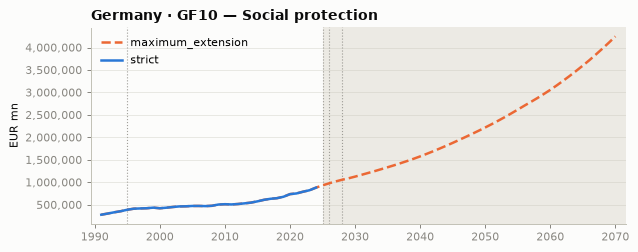

recipe:   1991-1994: backward stitch (IMF_GFS, grade B)  ·  1995-2024: anchor outturn
          (EUROSTAT_GOV10A_EXP, grade A)  ·  2025: forward stitch (EC_AMECO, grade C)  ·  2026-2027:
          proxy forecast (EC_AMECO, grade C)  ·  2028-2070: composite forecast (EC_AGEING_2024, grade C)
outturn:  1991-2025
strict:   NO PROJECTION — the only candidate covers too little of the line to enter strict. AR
          pensions+LTC composite measured at 61% of GF10 (grade C); BMAS Rentenversicherungsbericht
          blocked (bmas.de egress, OQ-6) — no strict forecast; maximum_extension chains the AMECO D.62
          proxy (to 2027) into the AR composite (to 2070) per D12
maximum:  projects to 2070 — [grade_below_strict] AR pensions+LTC composite measured at 61% of GF10
          (grade C); BMAS Rentenversicherungsbericht blocked (bmas.de egress, OQ-6) — no strict
          forecast; maximum_extension chains the AMECO D.62 proxy (to 2027) into the AR composite (to
          2070) per D12


In [72]:
chart("DEU", "GF10")

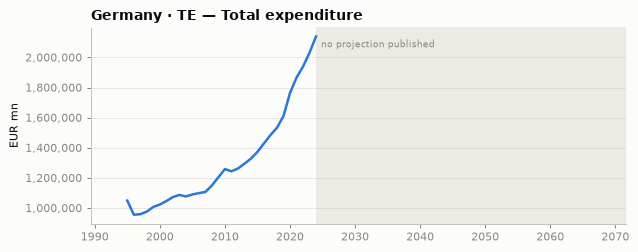

recipe:   1995-2024: anchor outturn (EUROSTAT_GOV10A_EXP, grade A)
outturn:  1995-2024
strict:   NO PROJECTION — a total, deliberately not given a forecast path of its own. totals are
          envelopes (§6.1, D4): the envelope constrains V15 but is not published as a stitched TE path
maximum:  NO PROJECTION — a total, deliberately not given a forecast path of its own. totals are
          envelopes (§6.1, D4): the envelope constrains V15 but is not published as a stitched TE path


In [73]:
chart("DEU", "TE")

## 3.2 Revenue — ESA

Ten revenue types from VAT through to other transfers receivable, and total revenue.

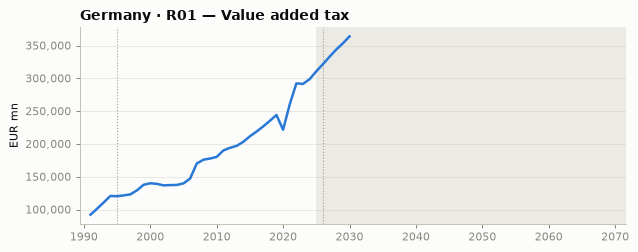

recipe:   1991-1994: backward stitch (OECD_RS, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2030: official forecast (DEU_STEUERSCHAETZUNG, grade
          B)
outturn:  1991-2025
strict:   projects to 2030 — source horizon: DEU_STEUERSCHAETZUNG ends 2030 (V10)
maximum:  projects to 2030 — source horizon: DEU_STEUERSCHAETZUNG ends 2030 (V10)


In [74]:
chart("DEU", "R01")

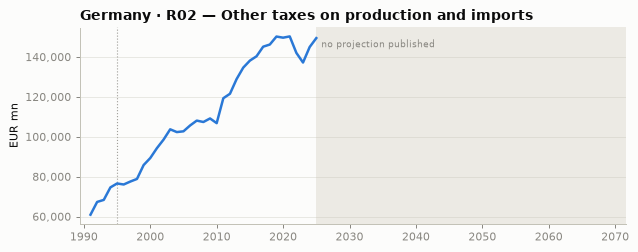

recipe:   1991-1994: backward stitch (OECD_RS, grade B)  ·  1995-2025: derived by identity
          (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1991-2025
strict:   NO PROJECTION — the candidate source has no ESA-complete machine-readable series.
          Steuerschätzung publishes Länder-/Gemeindesteuern only as cash aggregates mixing D.2, D.59 and
          D.91 — no ESA-complete component set for D.2 minus D.211; AMECO UTVG is total D.2 only
maximum:  NO PROJECTION — the candidate source has no ESA-complete machine-readable series.
          Steuerschätzung publishes Länder-/Gemeindesteuern only as cash aggregates mixing D.2, D.59 and
          D.91 — no ESA-complete component set for D.2 minus D.211; AMECO UTVG is total D.2 only


In [75]:
chart("DEU", "R02")

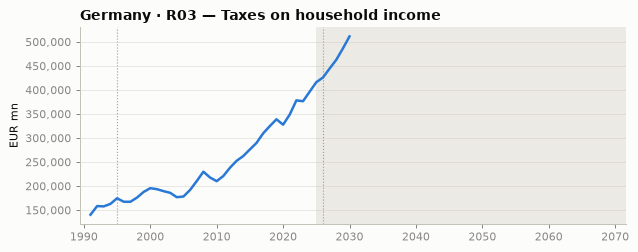

recipe:   1991-1994: backward stitch (OECD_RS, grade B)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2030: composite forecast (DEU_STEUERSCHAETZUNG, grade
          B)
outturn:  1991-2025
strict:   projects to 2030 — source horizon: DEU_STEUERSCHAETZUNG ends 2030 (V10)
maximum:  projects to 2030 — source horizon: DEU_STEUERSCHAETZUNG ends 2030 (V10)


In [76]:
chart("DEU", "R03")

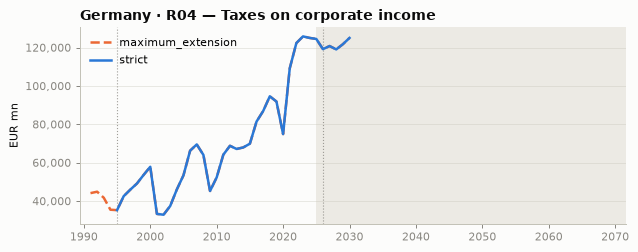

recipe:   1991-1994: backward stitch (OECD_RS, grade C)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2030: composite forecast (DEU_STEUERSCHAETZUNG, grade
          B)
outturn:  1991-2025
strict:   projects to 2030 — source horizon: DEU_STEUERSCHAETZUNG ends 2030 (V10)
maximum:  projects to 2030 — source horizon: DEU_STEUERSCHAETZUNG ends 2030 (V10)


In [77]:
chart("DEU", "R04")

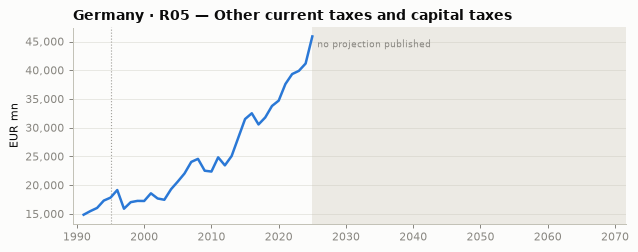

recipe:   1991-1994: backward stitch (OECD_RS, grade B)  ·  1995-2025: derived by identity
          (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1991-2025
strict:   NO PROJECTION — the only candidate covers too little of the line to enter strict. AMECO UTKG
          covers 34% of the line (D, not applied); Erbschaftsteuer is not separately published in the
          Steuerschätzung tables; D7 lists R05 as partial
maximum:  NO PROJECTION — the only candidate covers too little of the line to enter strict. AMECO UTKG
          covers 34% of the line (D, not applied); Erbschaftsteuer is not separately published in the
          Steuerschätzung tables; D7 lists R05 as partial


In [78]:
chart("DEU", "R05")

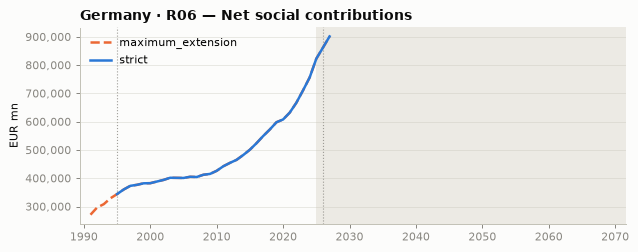

recipe:   1991-1994: backward stitch (OECD_RS, grade C)  ·  1995-2025: anchor outturn
          (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: official forecast (EC_AMECO, grade A)
outturn:  1991-2025
strict:   projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)
maximum:  projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [79]:
chart("DEU", "R06")

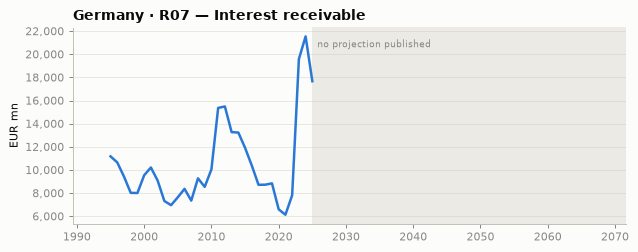

recipe:   1995-2025: anchor outturn (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1995-2025
strict:   NO PROJECTION — the candidate source has no ESA-complete machine-readable series. no usable GG
          interest-receivable forecast: AMECO has no D.41 resources series (UYVG is subsidies); DSM
          publishes payable interest only; the OBR 'PS interest and dividend receipts' candidate
          (D-S7-003) mixes dividends and the PS perimeter into the line and measures outside every band
          — recorded, not applied; NI/PB forecast ledger therefore stays empty (§4.3)
maximum:  NO PROJECTION — the candidate source has no ESA-complete machine-readable series. no usable GG
          interest-receivable forecast: AMECO has no D.41 resources series (UYVG is subsidies); DSM
          publishes payable interest only; the OBR 'PS interest and dividend receipts' candidate
          (D-S7-003) mixes dividends and the PS perimeter into the line and measures outside every band
          — re

In [80]:
chart("DEU", "R07")

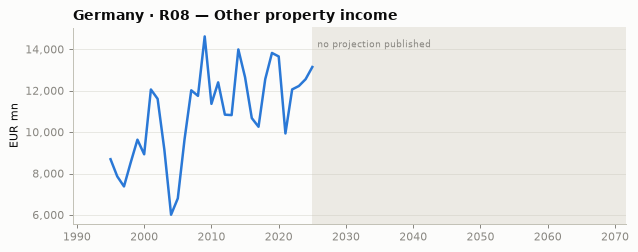

recipe:   1995-2025: derived by identity (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1995-2025
strict:   NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
maximum:  NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual


In [81]:
chart("DEU", "R08")

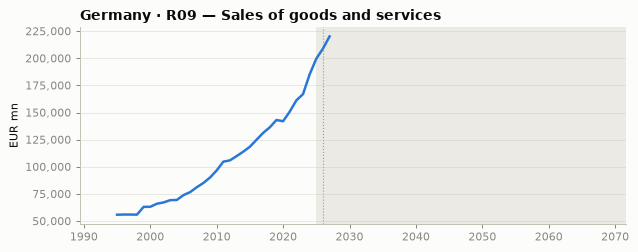

recipe:   1995-2025: anchor outturn (EUROSTAT_GOV10A_MAIN, grade A)  ·  2026-2027: composite forecast
          (EC_AMECO, grade B)
outturn:  1995-2025
strict:   projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)
maximum:  projects to 2027 — source horizon: EC_AMECO ends 2027 (V10)


In [82]:
chart("DEU", "R09")

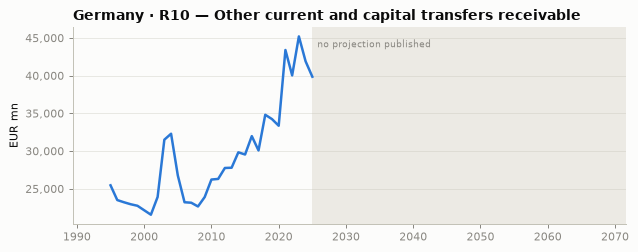

recipe:   1995-2025: derived by identity (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1995-2025
strict:   NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual
maximum:  NO PROJECTION — nobody publishes a forecast of this line on a compatible concept. D7: no
          official forecast identified anywhere (seed register and Stage 3 search: AMECO GG aggregates,
          AR 2024, DSM 2025, Steuerschätzung); strict and maximum end at the last actual


In [83]:
chart("DEU", "R10")

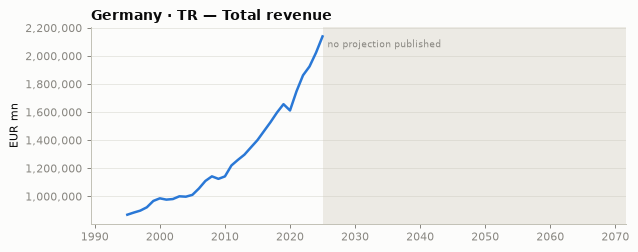

recipe:   1995-2025: anchor outturn (EUROSTAT_GOV10A_MAIN, grade A)
outturn:  1995-2025
strict:   NO PROJECTION — a total, deliberately not given a forecast path of its own. totals are
          envelopes (§6.1, D4): used in V15 only
maximum:  NO PROJECTION — a total, deliberately not given a forecast path of its own. totals are
          envelopes (§6.1, D4): used in V15 only


In [84]:
chart("DEU", "TR")

## 3.3 Balance ledger

Outturn years only, single line each — the two variants are identical here. TR and TE are the balance anchor's own totals, not sums of the lines above.

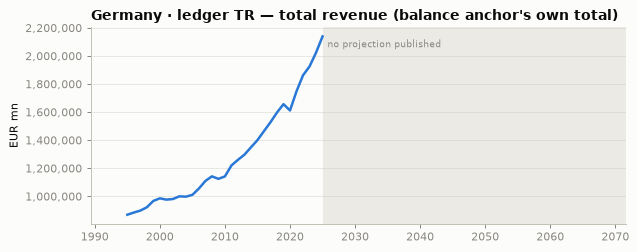

outturn:  1995-2025, source EUROSTAT_GOV10A_MAIN
forecast: NO PROJECTION — the ledger is outturn-only by design. Building it forward would mean summing
          lines whose forecast coverage is partial, which would misstate the totals; the forecast-side
          comparison lives in section 4 instead, where the coverage gap is explicit.


In [85]:
ledger_chart("DEU", "TR")

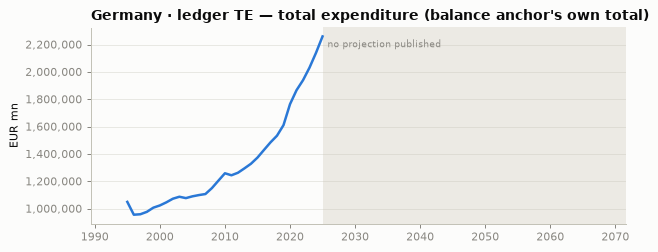

outturn:  1995-2025, source EUROSTAT_GOV10A_MAIN
forecast: NO PROJECTION — the ledger is outturn-only by design. Building it forward would mean summing
          lines whose forecast coverage is partial, which would misstate the totals; the forecast-side
          comparison lives in section 4 instead, where the coverage gap is explicit.


In [86]:
ledger_chart("DEU", "TE")

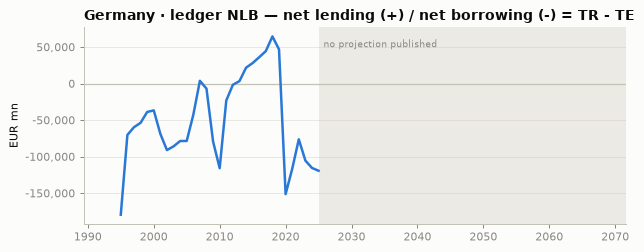

outturn:  1995-2025, source EUROSTAT_GOV10A_MAIN
forecast: NO PROJECTION — the ledger is outturn-only by design. Building it forward would mean summing
          lines whose forecast coverage is partial, which would misstate the totals; the forecast-side
          comparison lives in section 4 instead, where the coverage gap is explicit.


In [87]:
ledger_chart("DEU", "NLB")

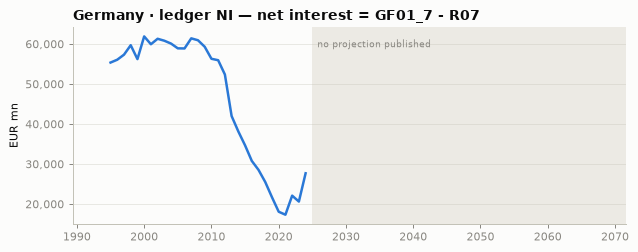

outturn:  1995-2025, source EUROSTAT_GOV10A_MAIN; no value for [2025]
forecast: NO PROJECTION — the ledger is outturn-only by design. Building it forward would mean summing
          lines whose forecast coverage is partial, which would misstate the totals; the forecast-side
          comparison lives in section 4 instead, where the coverage gap is explicit.


In [88]:
ledger_chart("DEU", "NI")

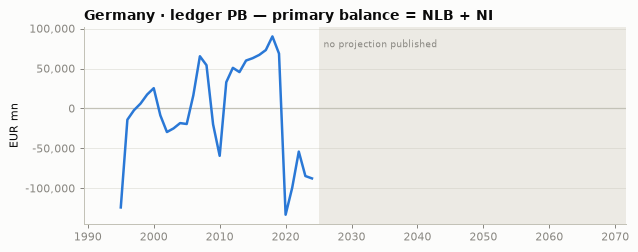

outturn:  1995-2025, source EUROSTAT_GOV10A_MAIN; no value for [2025]
forecast: NO PROJECTION — the ledger is outturn-only by design. Building it forward would mean summing
          lines whose forecast coverage is partial, which would misstate the totals; the forecast-side
          comparison lives in section 4 instead, where the coverage gap is explicit.


In [89]:
ledger_chart("DEU", "PB")

---

# 4. Reconciliation to the IMF WEO

Do our totals agree with the IMF's? Each chart puts our number and the WEO's on
the same axes over every overlap year, with the gap as a percentage of our total
expenditure underneath.

What to look for: a gap that is **small and flat** is a definitional
difference — a stable perimeter wedge — and is fine. A gap that **drifts or
jumps** is a vintage difference or something that needs explaining, and the
`gap_classification` column in the caption says which the pipeline decided it
was (`perimeter`, `revision`, or `unexplained`).

These are history-only, because our ledger is history-only: the WEO's forecast
has nothing on our side to sit beside. §4.4 handles the forecast side, where the
comparison is a decomposition rather than a level. There is therefore no
projection region to shade here, and the shared country x-axis of sections 1–3
is not used: these charts compare two lines *inside* one chart, and stretching
them to 2070 would squeeze the gap panel — the part carrying the answer — into
a quarter of the width.

## 4.1 United Kingdom

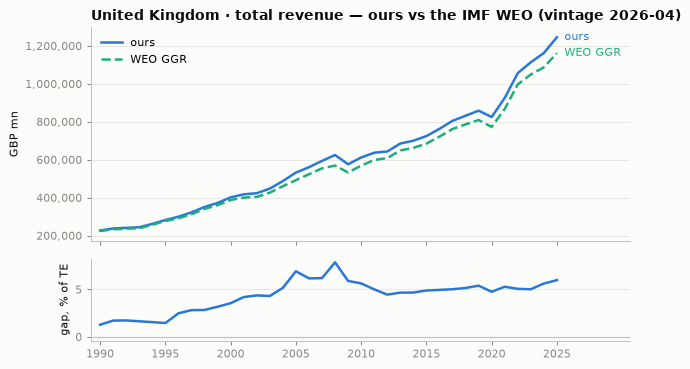

overlap 1990-2025; gap mean +4.355% of TE, sigma 1.662, range +1.281 to +7.849; classified: perimeter, unexplained


In [90]:
weo_chart("GBR", "revenue")

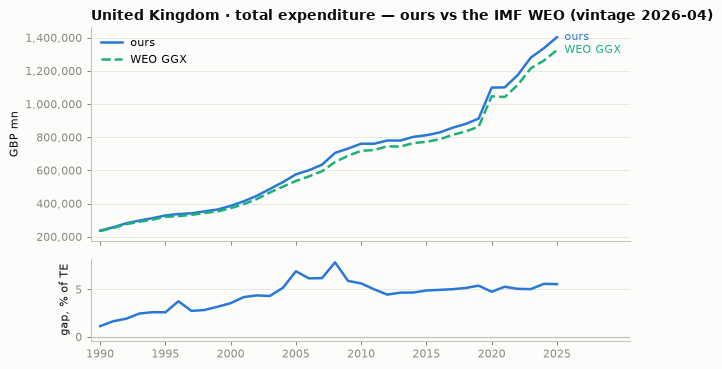

overlap 1990-2025; gap mean +4.458% of TE, sigma 1.500, range +1.130 to +7.849; classified: perimeter, unexplained


In [91]:
weo_chart("GBR", "expenditure")

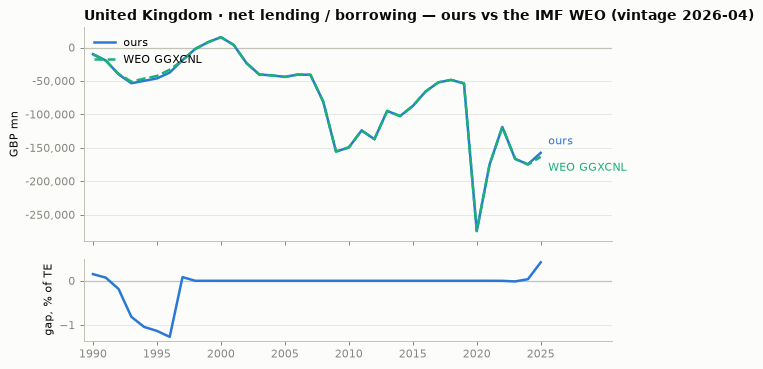

overlap 1990-2025; gap mean -0.103% of TE, sigma 0.358, range -1.267 to +0.417; classified: perimeter, unexplained


In [92]:
weo_chart("GBR", "nlb")

## 4.2 France

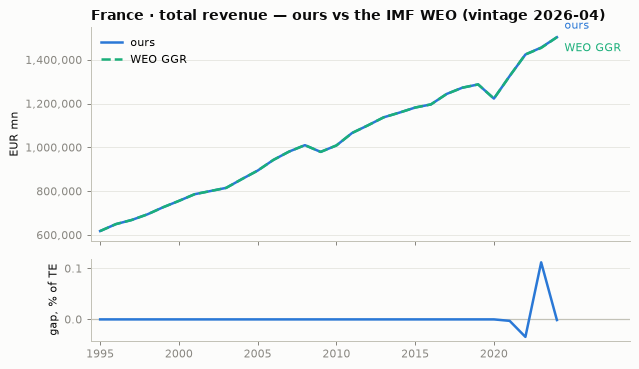

overlap 1995-2024; gap mean +0.002% of TE, sigma 0.022, range -0.034 to +0.112; classified: revision


In [93]:
weo_chart("FRA", "revenue")

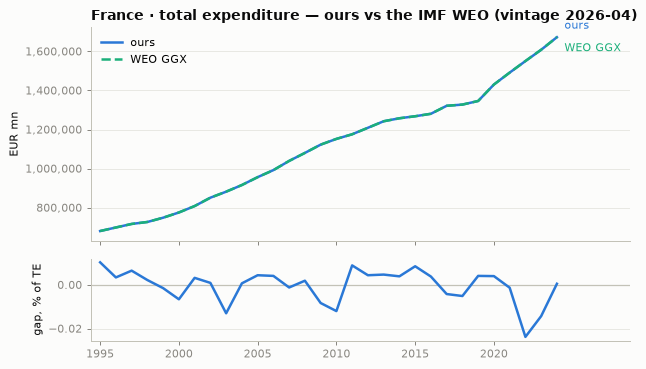

overlap 1995-2024; gap mean -0.000% of TE, sigma 0.008, range -0.024 to +0.010; classified: revision


In [94]:
weo_chart("FRA", "expenditure")

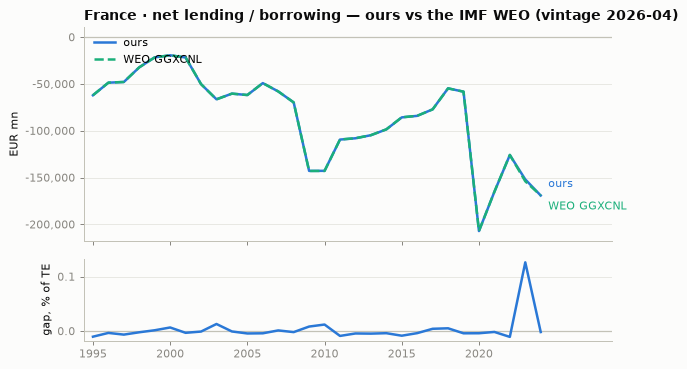

overlap 1995-2024; gap mean +0.003% of TE, sigma 0.024, range -0.011 to +0.126; classified: revision


In [95]:
weo_chart("FRA", "nlb")

## 4.3 Germany

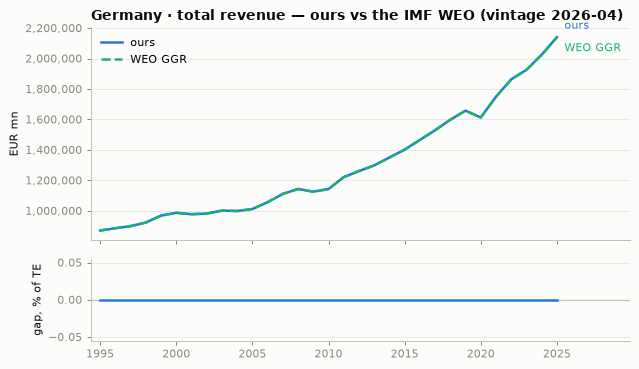

overlap 1995-2025; gap mean +0.000% of TE, sigma 0.000, range +0.000 to +0.000; classified: revision


In [96]:
weo_chart("DEU", "revenue")

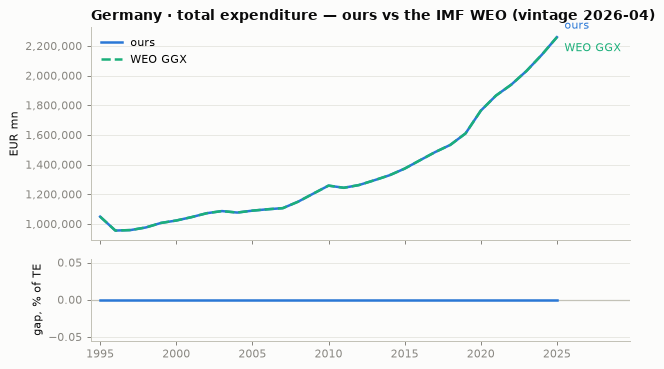

overlap 1995-2025; gap mean +0.000% of TE, sigma 0.000, range +0.000 to +0.000; classified: revision


In [97]:
weo_chart("DEU", "expenditure")

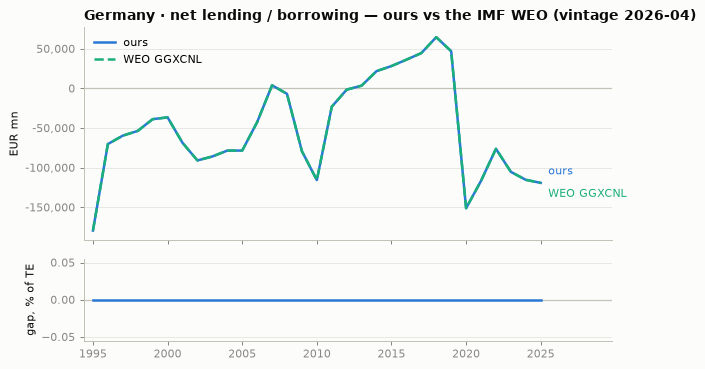

overlap 1995-2025; gap mean +0.000% of TE, sigma 0.000, range +0.000 to +0.000; classified: revision


In [98]:
weo_chart("DEU", "nlb")

## 4.4 The forecast side

Levels cannot be compared past the last outturn, so the forecast side asks a
different question: **of the change in the balance the WEO projects, how much do
our published line-level forecasts account for?** That is `explained_share` —
1.0 means fully accounted for, 0.0 means the projected move sits entirely in
residuals nobody publishes a forecast for.

A low share is a fact about the availability of official forecasts, not an error
in the data. Negative values mean the covered lines move *against* the WEO's
projected direction.

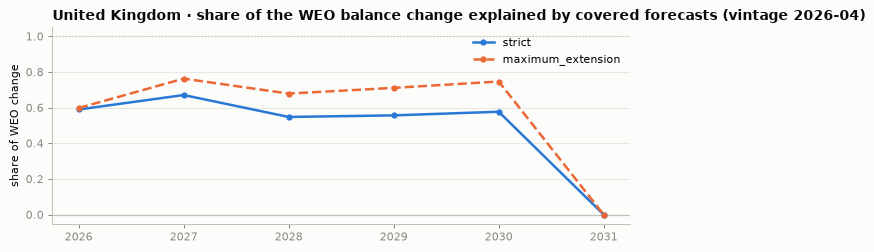

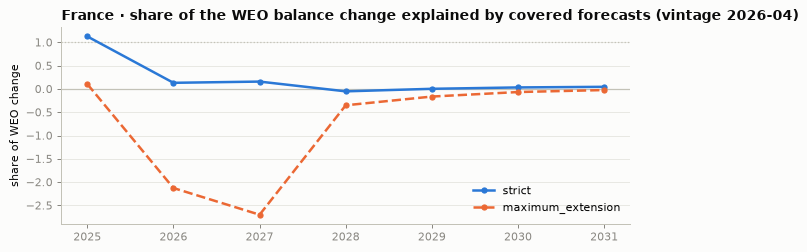

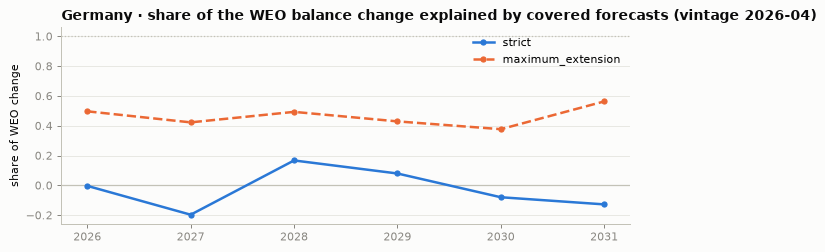

In [99]:
def explained_share(iso3, vintage=None):
    vintage = vintage or LATEST
    d = RECON.query("block == 'forecast' and component == 'explained_share' "
                    "and iso3 == @iso3 and weo_vintage == @vintage")
    fig, ax = plt.subplots()
    for variant, colour, style in (("strict", BLUE, "-"),
                                   ("maximum_extension", ORANGE, "--")):
        s = d.query("variant == @variant").sort_values("year")
        ax.plot(s.year, s.contribution_pp, color=colour, ls=style,
                marker="o", markersize=4, label=variant)
    ax.axhline(0, color=AXIS, lw=1, zorder=0)
    ax.axhline(1, color=AXIS, lw=1, ls=":", zorder=0)
    ax.set_title(f"{NAME[iso3]} · share of the WEO balance change explained "
                 f"by covered forecasts (vintage {vintage})")
    ax.set_ylabel("share of WEO change")
    ax.grid(axis="y")
    ax.legend(loc="best")
    fig.tight_layout()
    plt.show()


for iso3 in ("GBR", "FRA", "DEU"):
    explained_share(iso3)

---

# 5. The two TE numbers

Point 5 of the schema notes, charted. The COFOG tree's `TE` comes from the
expenditure anchor; the ledger's `TE` comes from the balance anchor. For France
and Germany these are the same Eurostat table and agree to rounding. For the UK
they are two different ONS tables — ESA Table 11 against the general-government
receipts-and-expenditure table — so they can and do differ.

Neither is wrong. They are different published totals, and the pipeline keeps
both rather than picking one, so which anchor a number came from stays visible.

Both series are outturn-only, so as in §4 there is no projection region and the
charts keep their own span rather than the shared country axis.

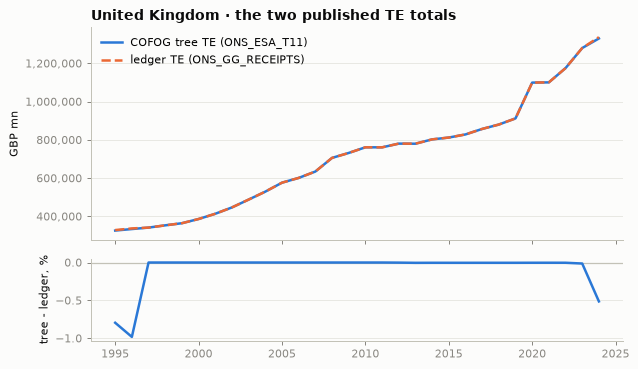

worst absolute difference 0.9808% in 1996


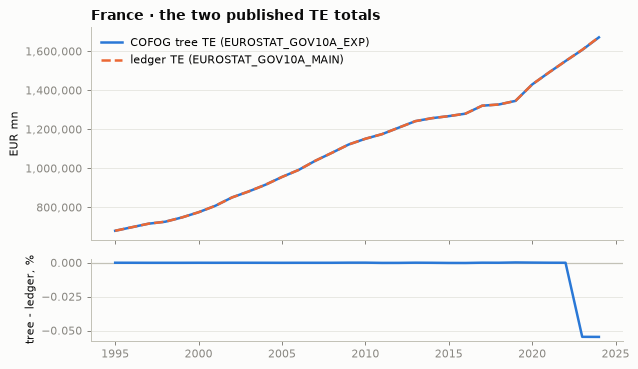

worst absolute difference 0.0547% in 2024


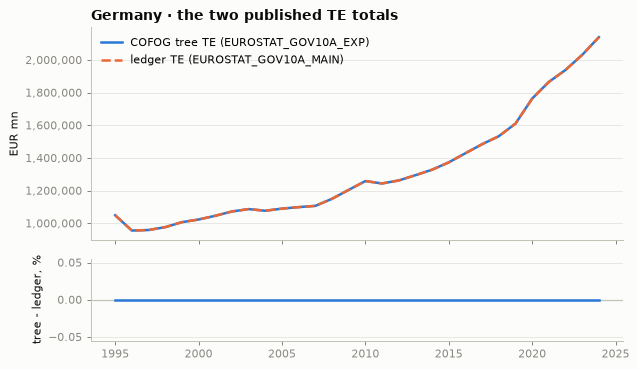

worst absolute difference 0.0000% in 1995


In [100]:
def te_compare(iso3):
    tree = (TREE.query("iso3 == @iso3 and line_code == 'TE' and "
                       "variant == 'strict'").sort_values("year"))
    led = LEDGER.query("iso3 == @iso3 and variant == 'strict'").sort_values("year")
    both = tree[["year", "value_lcu_mn", "source_id"]].merge(
        led[["year", "te_lcu_mn", "source_id"]], on="year",
        suffixes=("_tree", "_ledger"))
    both["diff_pct"] = 100 * (both.value_lcu_mn - both.te_lcu_mn) / both.te_lcu_mn

    fig, (ax, gx) = plt.subplots(2, 1, figsize=(7.2, 4.2), sharex=True,
                                 height_ratios=[2.6, 1])
    ax.plot(both.year, both.value_lcu_mn, color=BLUE,
            label=f"COFOG tree TE ({both.source_id_tree.iloc[0]})")
    ax.plot(both.year, both.te_lcu_mn, color=ORANGE, ls="--",
            label=f"ledger TE ({both.source_id_ledger.iloc[0]})")
    ax.set_title(f"{NAME[iso3]} · the two published TE totals")
    ax.set_ylabel(f"{tree.currency.iloc[0]} mn")
    ax.grid(axis="y")
    thousands(ax)
    ax.legend(loc="upper left")

    gx.plot(both.year, both.diff_pct, color=BLUE)
    gx.axhline(0, color=AXIS, lw=1, zorder=0)
    gx.set_ylabel("tree - ledger, %")
    gx.grid(axis="y")
    gx.margins(x=0.03)
    fig.tight_layout()
    plt.show()
    print(f"worst absolute difference {both.diff_pct.abs().max():.4f}% "
          f"in {int(both.loc[both.diff_pct.abs().idxmax(), 'year'])}")


for iso3 in ("GBR", "FRA", "DEU"):
    te_compare(iso3)

---

# 6. Where the seams are

A last pass over the whole book: every seam in every series, counted and listed,
so nothing charted above goes unnoticed. Each row is a year where a series
changes source or construction method — the dotted rules in the charts.

In [101]:
rows = []
for (iso3, line), g in TREE.query("variant == 'maximum_extension'").groupby(
        ["iso3", "line_code"]):
    for year in _seams(g):
        prev = g.query("year == @year - 1").iloc[0]
        curr = g.query("year == @year").iloc[0]
        rows.append({"iso3": iso3, "line": line, "seam_year": year,
                     "from": f"{prev.observation_type} ({prev.source_id})",
                     "to": f"{curr.observation_type} ({curr.source_id})",
                     "step_pct": round(100 * (curr.value_lcu_mn
                                              / prev.value_lcu_mn - 1), 2)})
seams = pd.DataFrame(rows).sort_values(["iso3", "line", "seam_year"])
print(f"{len(seams)} seams across {seams.groupby(['iso3', 'line']).ngroups} series")
seams.reset_index(drop=True)

73 seams across 39 series


,iso3,line,seam_year,from,to,step_pct
0,DEU,GF01,1995,stitched_actual (IMF_GFS),anchor_actual (EUROSTAT_GOV10A_EXP),6.20
1,DEU,GF01,2025,anchor_actual (EUROSTAT_GOV10A_EXP),stitched_actual (EC_AMECO),8.11
2,DEU,GF01,2026,stitched_actual (EC_AMECO),proxy_forecast (EC_AMECO),7.70
3,DEU,GF01_7,1995,stitched_actual (EC_AMECO),level2_proxy_actual (EUROSTAT_GOV10A_EXP),9.82
4,DEU,GF01_7,2000,level2_proxy_actual (EUROSTAT_GOV10A_EXP),anchor_actual (EUROSTAT_GOV10A_EXP),11.21
...,...,...,...,...,...,...
68,GBR,R04,2026,anchor_actual (ONS_GG_RECEIPTS),composite_forecast (OBR_EFO_LATEST),2.94
69,GBR,R05,2026,derived_actual (ONS_GG_RECEIPTS),composite_forecast (OBR_EFO_LATEST),6.54
70,GBR,R06,1990,stitched_actual (OECD_RS),anchor_actual (ONS_GG_RECEIPTS),5.75
71,GBR,R06,2026,anchor_actual (ONS_GG_RECEIPTS),direct_forecast (EC_AMECO),4.00


`step_pct` is the year-on-year change *across* the seam. It is not an error
term — spending and revenue really do change from year to year — but an
outsized value at a seam is the first place to look if a series seems wrong. Sort
by it to triage:

In [102]:
seams.reindex(seams.step_pct.abs().sort_values(ascending=False).index).head(15)

,iso3,line,seam_year,from,to,step_pct
10,DEU,GF04,1995,stitched_actual (IMF_GFS),anchor_actual (EUROSTAT_GOV10A_EXP),141.04
15,DEU,GF08,1995,stitched_actual (IMF_GFS),anchor_actual (EUROSTAT_GOV10A_EXP),38.67
65,GBR,R03,1990,stitched_actual (OECD_RS),anchor_actual (ONS_GG_RECEIPTS),22.57
34,FRA,GF01,2026,stitched_actual (EC_AMECO),proxy_forecast (EC_AMECO),19.04
37,FRA,GF01_7,2026,stitched_actual (EC_AMECO),direct_forecast (EC_AMECO),19.04
55,GBR,GF01_7,2025,anchor_actual (ONS_ESA_T11),stitched_actual (EC_AMECO),18.81
51,GBR,GF01,2025,anchor_actual (ONS_ESA_T11),stitched_actual (EC_AMECO),18.81
7,DEU,GF01_7,2028,direct_forecast (EC_AMECO),direct_forecast (EC_DSM),15.99
54,GBR,GF01_7,1995,stitched_actual (ONS_PSF_INTEREST),anchor_actual (ONS_ESA_T11),14.67
67,GBR,R04,1990,stitched_actual (OECD_RS),anchor_actual (ONS_GG_RECEIPTS),-14.35
